# Детская депривация в Казахстане, 2021–2024: факторы и ассоциации

**Данные:** формы D002/D002-КазРус (депривация, материальное положение, продовольственная
безопасность), D006 (жилищные условия), D008 (состав домохозяйства), **D004** (доходы,
расходы, алименты — построчные данные `kv_vopr_detail_<year>.csv`, декодированы по
тексту бланка `д004_форма_рус.pdf`). Панель домохозяйств 2021–2024 гг., поквартальные
наблюдения.

**Часть I. Основная гипотеза.** Уровень детской депривации связан с регионом и типом
населённого пункта текущего проживания, материальным положением (включая доход и
государственные пособия), продовольственной безопасностью, жилищными условиями,
полнотой семьи и структурой домохозяйства.

*(Исходная формулировка касалась «места рождения» ребёнка; в ходе аудита выяснилось,
что поле `Mes_rojd` — это месяц, а не место рождения (подтверждено структурой D008).
Данных о месте рождения в файлах нет, поэтому гипотеза сформулирована через регион/тип
поселения текущего проживания.)*

**Часть I, производная гипотеза (Н1′).** Депривация различается по конкретным пунктам
(одежда, обувь, питание, книги/игрушки, досуг, отпуск, медицина и т.д.), по полноте семьи
(полная/неполная) и по региону/поселению — не только на уровне агрегированного индекса.

**Часть II. Гипотеза Н2.** Шансы наличия детей в домохозяйстве выше при собственном
благоустроенном жилье и стабильно высоком доходе.

**Использованные формы:** D002/D002-КазРус, D006, D008, **D004** (доходы — совокупные и
по категориям, включая государственные пособия семьям с детьми; алименты выплаченные —
отдельно; колонка «алименты полученные» не прошла валидацию, см. Milestone 1.4). Все четыре формы участвуют в анализе на равных правах, начиная
с этапа аудита.

**Методологическая схема:** аудит данных → сопоставление переменных → гармонизация →
объединение форм → аналитическая выборка → построение показателей → описательная
статистика → визуализация → статистические тесты → регрессия → robustness →
интерпретация → выводы.

> **Технический комментарий по ресурсам.** Годовые файлы `D00X_master_wide_<year>.csv`
> содержат ~167–171 тыс. строк × 510 столбцов (~0.6–0.7 ГБ в памяти). Файлы
> `kv_vopr_detail_<year>.csv` — построчная (ragged, не прямоугольная) выгрузка 12
> под-таблиц формы D004, ~2 млн строк каждый; читаются не через `pandas`, а построчно
> (`csv.reader`) — см. Milestone 1. Чтобы ноутбук стабильно выполнялся при ограниченной
> памяти, данные не держатся одновременно в памяти за все 4 года — каждая ячейка читает
> нужные годы по очереди и освобождает память (`del df; gc.collect()`).


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import csv
import gc
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)

# --- Пути ---------------------------------------------------------------
CANDIDATE_DATA_DIRS = ["/content/drive/MyDrive/Datathon2026/synthetic_microdata_2021-2024_20260921/D00X/data", "data", "."]
DATA_DIR = next((Path(p) for p in CANDIDATE_DATA_DIRS if Path(p).exists() and
                  any(Path(p).glob("master_wide_*.csv"))), Path("data"))
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS = [2021, 2022, 2023, 2024]

def year_path(y):
    return DATA_DIR / f"master_wide_{y}.csv"

def d004_path(y):
    return DATA_DIR / f"kv_vopr_detail_{y}.csv"

def load_csv(y, usecols=None):
    return pd.read_csv(year_path(y), usecols=usecols, low_memory=False)

print("DATA_DIR:", DATA_DIR.resolve())
print("D002/D006/D008 файлы:", [year_path(y).name for y in YEARS if year_path(y).exists()])
print("D004 файлы:", [d004_path(y).name for y in YEARS if d004_path(y).exists()])


DATA_DIR: /content/drive/MyDrive/Datathon2026/synthetic_microdata_2021-2024_20260921/D00X/data
D002/D006/D008 файлы: ['master_wide_2021.csv', 'master_wide_2022.csv', 'master_wide_2023.csv', 'master_wide_2024.csv']
D004 файлы: ['kv_vopr_detail_2021.csv', 'kv_vopr_detail_2022.csv', 'kv_vopr_detail_2023.csv', 'kv_vopr_detail_2024.csv']


## 2. Загрузка данных


In [9]:
summary_rows = []
for y in YEARS:
    header = pd.read_csv(year_path(y), nrows=0).columns.tolist()
    n_rows = sum(1 for _ in open(year_path(y), encoding="utf-8", errors="replace")) - 1
    summary_rows.append({"year": y, "form": "master_wide (D002+D006+D008)",
                          "rows": n_rows, "columns": len(header)})
    n_rows_d004 = sum(1 for _ in open(d004_path(y), encoding="utf-8", errors="replace")) - 1
    summary_rows.append({"year": y, "form": "kv_vopr_detail (D004, 12 под-таблиц)",
                          "rows": n_rows_d004, "columns": "9-36 (ragged)"})

dataset_summary = pd.DataFrame(summary_rows)
dataset_summary


,year,form,rows,columns
0,2021,master_wide (D002+D006+D008),167472,510
1,2021,"kv_vopr_detail (D004, 12 под-таблиц)",1896805,9-36 (ragged)
2,2022,master_wide (D002+D006+D008),170724,510
3,2022,"kv_vopr_detail (D004, 12 под-таблиц)",1927946,9-36 (ragged)
4,2023,master_wide (D002+D006+D008),170756,510
5,2023,"kv_vopr_detail (D004, 12 под-таблиц)",213139,9-36 (ragged)
6,2024,master_wide (D002+D006+D008),167284,510
7,2024,"kv_vopr_detail (D004, 12 под-таблиц)",1931671,9-36 (ragged)


## Milestone 1 — Аудит данных

### 1.1 D002/D006/D008 — структура столбцов

Каждый столбец `D00X_master_wide` имеет префикс `d002_subject__`, `d002_ocenka__`,
`d006__` или `d008__` (кроме служебных идентификаторов). Проверяем идентичность
структуры по годам.

In [10]:
def col_group(c):
    for pref in ("d002_subject__", "d002_ocenka__", "d006__", "d008__"):
        if c.startswith(pref):
            return pref.rstrip("_")
    return "id/service"

headers = {y: pd.read_csv(year_path(y), nrows=0).columns.tolist() for y in YEARS}
group_counts = pd.DataFrame({
    y: pd.Series([col_group(c) for c in headers[y]]).value_counts()
    for y in YEARS
}).fillna(0).astype(int)
group_counts


,2021,2022,2023,2024
d006,244,244,244,244
d002_ocenka,116,116,116,116
d002_subject,108,108,108,108
d008,30,30,30,30
id/service,12,12,12,12


In [11]:
identical = {y: headers[y] == headers[2021] for y in YEARS}
print("Идентичность столбцов D00X_master_wide относительно 2021:", identical)


Идентичность столбцов D00X_master_wide относительно 2021: {2021: True, 2022: True, 2023: True, 2024: True}


### 1.2 Единица наблюдения и идентификаторы (D002/D006/D008)

In [12]:
id_summary_rows = []
for y in YEARS:
    df = load_csv(y, usecols=["HOUSEHOLD_ID", "NOMP", "KVARTAL", "TE"])
    n = len(df)
    n_hh = df["HOUSEHOLD_ID"].nunique()
    dup = df.duplicated(subset=["HOUSEHOLD_ID", "NOMP", "KVARTAL"]).sum()
    id_summary_rows.append({
        "year": y, "rows": n, "households": n_hh, "rows_per_hh": round(n / n_hh, 2),
        "quarters": sorted(df["KVARTAL"].dropna().unique().tolist()),
        "dup_(hh,person,quarter)": dup, "regions_TE": df["TE"].nunique(),
    })
    del df; gc.collect()
id_summary = pd.DataFrame(id_summary_rows)
id_summary


,year,rows,households,rows_per_hh,quarters,"dup_(hh,person,quarter)",regions_TE
0,2021,167472,12000,13.96,"[1, 2, 3, 4]",0,17
1,2022,170724,12000,14.23,"[1, 2, 3, 4]",0,20
2,2023,170756,12000,14.23,"[1, 2, 3, 4]",0,20
3,2024,167284,12000,13.94,"[1, 2, 3, 4]",0,20




### 1.3 D004 — структура файла (реверс-инжиниринг)


In [13]:
def d004_table_counts(y):
    counts = {}
    field_counts = {}
    with open(d004_path(y), encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            st = row[-1]
            counts[st] = counts.get(st, 0) + 1
            field_counts.setdefault(st, len(row))
    return counts, field_counts

d004_counts_2021, d004_fields_2021 = d004_table_counts(2021)
d004_table_summary = pd.DataFrame([
    {"source_table": k, "n_fields": d004_fields_2021[k], "rows_2021": v}
    for k, v in sorted(d004_counts_2021.items())
])
d004_table_summary


,source_table,n_fields,rows_2021
0,kv_vopr_0_combined,9,48000
1,kv_vopr_10_combined,15,42109
2,kv_vopr_11_combined,36,99082
3,kv_vopr_12_combined,15,20399
4,kv_vopr_1_combined,13,1092444
5,kv_vopr_2_combined,12,250452
6,kv_vopr_3_combined,11,105758
7,kv_vopr_4_combined,11,6880
8,kv_vopr_5_combined,11,19941
9,kv_vopr_6_combined,13,154115


In [14]:
field_stability = {}
for y in YEARS:
    _, fc = d004_table_counts(y)
    field_stability[y] = fc
field_stability_df = pd.DataFrame(field_stability)
print("Число полей по под-таблицам, идентично во всех годах:",
      (field_stability_df.nunique(axis=1) == 1).all())
field_stability_df


Число полей по под-таблицам, идентично во всех годах: True


,2021,2022,2023,2024
kv_vopr_0_combined,9,9,9.0,9
kv_vopr_10_combined,15,15,15.0,15
kv_vopr_11_combined,36,36,36.0,36
kv_vopr_12_combined,15,15,15.0,15
kv_vopr_1_combined,13,13,NaN,13
kv_vopr_2_combined,12,12,NaN,12
kv_vopr_3_combined,11,11,NaN,11
kv_vopr_4_combined,11,11,NaN,11
kv_vopr_5_combined,11,11,NaN,11
kv_vopr_6_combined,13,13,NaN,13


### 1.4 D004 — декодирование колонок `kv_vopr_11_combined` (Доходы) и `kv_vopr_6_combined` (прочие фин. расходы)

Позиции служебных полей (`KVARTAL` и др.) для двух ключевых под-таблиц определены
эмпирически (поиск столбца с равномерным распределением значений {1,2,3,4}) и
подтверждены точным текстом бланка `д004_форма_рус.pdf` (раздел «3. Доходы» даёт полный
перечень из 23 категорий `GR1…GR23`; раздел «1.3 Прочие финансовые расходы» содержит
пункт «Расходы по выплате алиментов», сопоставленный со справочником
`kv_vopr6_проч_финансовые_расходы_.xls`, код `21123`).

Разреженность (доля ненулевых строк) и типичные суммы по каждой из 24 колонок
`kv_vopr_11_combined` сопоставлены с ожидаемой распространённостью каждой из 23
категорий бланка (например, доход по найму — самая частая и крупная категория; продажа
недвижимости — редкая, но с огромными суммами) — это и есть способ проверки
сопоставления при отсутствии прямого файла-словаря для этой под-таблицы.

In [15]:
GR_LABELS = {
    "GR1": "Доход от работы по найму", "GR2": "Доход от работы не по найму",
    "GR3": "  из него: продажа с/х продукции (подкатегория GR2)",
    "GR4": "Пенсии по возрасту", "GR5": "Стипендии", "GR6": "Адресная социальная помощь",
    "GR7": "Жилищная помощь", "GR8": "Гос. пособия семьям с детьми",
    "GR9": "Государственное социальное пособие", "GR10": "Специальное государственное пособие",
    "GR11": "Другие трансферты от государства", "GR12": "Социальные трансферты в натуральной форме",
    "GR13": "Материальная помощь (денежная)", "GR14": "Материальная помощь (натуральная)",
    "GR15": "Прочие трансферты", "GR16": "Алименты (получено)",
    "GR17": "Доход от продажи недвижимости", "GR18": "Доход от продажи личного имущества",
    "GR19": "Доход от собственности (дивиденды, %, гонорары)", "GR20": "Аренда жилья (доход)",
    "GR21": "Аренда земли/техники (доход)", "GR22": "Прочие денежные поступления",
    "GR23": "Дотации и льготы",
}
# позиция в сыром файле = 7..29 для GR1..GR23 (позиция 6 - технический столбец, не доход)
GR_POSITIONS = {f"GR{i}": 6 + i for i in range(1, 24)}

def profile_income_columns(y):
    nz = {k: 0 for k in GR_POSITIONS}
    tot_sum = {k: 0.0 for k in GR_POSITIONS}
    n = 0
    with open(d004_path(y), encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if row[-1] != "kv_vopr_11_combined":
                continue
            n += 1
            for k, pos in GR_POSITIONS.items():
                try:
                    v = float(row[pos])
                except ValueError:
                    v = 0.0
                if v != 0:
                    nz[k] += 1
                    tot_sum[k] += v
    rows = [{"category": k, "label": GR_LABELS[k], "nonzero_share": round(nz[k] / n, 4),
             "mean_if_nonzero": round(tot_sum[k] / nz[k], 0) if nz[k] else 0}
            for k in GR_POSITIONS]
    return pd.DataFrame(rows).set_index("category")

income_category_profile = profile_income_columns(2021)
income_category_profile


,label,nonzero_share,mean_if_nonzero
category,,,
GR1,Доход от работы по найму,0.5876,348457.0
GR2,Доход от работы не по найму,0.1023,291303.0
GR3,из него: продажа с/х продукции (подкатегория...,0.0331,180858.0
GR4,Пенсии по возрасту,0.2505,280270.0
GR5,Стипендии,0.0229,81714.0
GR6,Адресная социальная помощь,0.0013,124335.0
GR7,Жилищная помощь,0.0004,37157.0
GR8,Гос. пособия семьям с детьми,0.0352,140732.0
GR9,Государственное социальное пособие,0.0490,145582.0


In [16]:
def _sf(x):
    try:
        return float(x)
    except (ValueError, TypeError):
        return 0.0

def validate_income_columns(y=2023, grs=("GR1", "GR4", "GR8", "GR16")):
    # Внешняя валидация расшифровки колонок дохода: (а) доля ДХ с ненулевым значением в группах
    # "без детей" / "дети + партнёр" / "дети без партнёра" (по D008); (б) доля лиц с ненулевым
    # значением среди женщин и мужчин (POL в D004). Ожидание: пособие семьям с детьми и алименты
    # должны концентрироваться в ДХ с детьми и (для алиментов) — у женщин / неполных семей.
    mw = load_csv(y, usecols=["HOUSEHOLD_ID", "NOMP", "d008__RODSTVO", "d008__GOD_ROJD"]).drop_duplicates(["HOUSEHOLD_ID", "NOMP"])
    child = ((y - mw["d008__GOD_ROJD"]) < 18).groupby(mw["HOUSEHOLD_ID"]).any()
    spouse = (mw["d008__RODSTVO"] == 2).groupby(mw["HOUSEHOLD_ID"]).any()
    grp = pd.Series(np.where(~child, "без детей", np.where(spouse, "дети, есть партнёр", "дети, нет партнёра")), index=child.index)
    hh_sets = {g: set() for g in grs}
    sex_nz = {g: {"1": 0, "2": 0} for g in grs}
    sex_tot = {"1": 0, "2": 0}
    with open(d004_path(y), encoding="utf-8") as f:
        reader = csv.reader(f); next(reader)
        for row in reader:
            if row[-1] != "kv_vopr_11_combined":
                continue
            sex = row[4]
            if sex in sex_tot:
                sex_tot[sex] += 1
            for g in grs:
                if _sf(row[GR_POSITIONS[g]]) != 0:
                    hh_sets[g].add(int(row[-2]))
                    if sex in sex_tot:
                        sex_nz[g][sex] += 1
    rows = []
    for g in grs:
        s = hh_sets[g]
        r = {"category": g, "label": GR_LABELS[g]}
        for name in ["без детей", "дети, есть партнёр", "дети, нет партнёра"]:
            idx = grp.index[grp == name]
            r[f"hh_share: {name}"] = round(idx.isin(list(s)).mean(), 3)
        r["женщины, % лиц"] = round(100 * sex_nz[g]["2"] / sex_tot["2"], 2)
        r["мужчины, % лиц"] = round(100 * sex_nz[g]["1"] / sex_tot["1"], 2)
        rows.append(r)
    return pd.DataFrame(rows).set_index("category")

income_validation = validate_income_columns(2023)
income_validation


,label,hh_share: без детей,"hh_share: дети, есть партнёр","hh_share: дети, нет партнёра","женщины, % лиц","мужчины, % лиц"
category,,,,,,
GR1,Доход от работы по найму,0.813,0.986,0.922,55.41,69.26
GR4,Пенсии по возрасту,0.585,0.350,0.367,26.66,15.17
GR8,Гос. пособия семьям с детьми,0.064,0.358,0.161,7.55,0.50
GR16,Алименты (получено),0.078,0.093,0.081,1.11,1.02


**Результат валидации (таблица выше, воспроизводится при каждом запуске):**

- **GR8 «гос. пособия семьям с детьми» — подтверждено.** Доля ДХ с пособием в разы выше
  в ДХ с детьми, чем без детей, и в ~15 раз чаще у женщин, чем у мужчин. Колонка
  расшифрована верно.
- **GR1 (доход по найму) и GR4 (пенсии)** — профили согласуются с ожиданием (зарплата чаще
  у мужчин, пенсии — у женщин, пенсионеры чаще в ДХ без детей).
- **GR16 «алименты (получено)» — НЕ подтверждено.** Ожидалось бы заметное сосредоточение у
  женщин и в ДХ с детьми (особенно без партнёра); фактически доли у мужчин/женщин и у ДХ с
  детьми/без практически равны. Порядковый номер 16 в перечне бланка не гарантирует, что
  колонка №22 файла — именно алименты (файл — построчная выгрузка без словаря столбцов).
  Поэтому **`alimony_received` трактуется как непроверенный показатель**: сохраняется в
  таблицах для описания, но **не используется в выводах и моделях**. Суммируемый в
  `total_income` вклад этой колонки не влияет на надёжность остальных компонент.
- **Алименты выплаченные** (`kv_vopr_6`, `KODNU=21123`) идентифицированы иначе — через
  официальный классификатор расходов (`kv_vopr6_проч_финансовые_расходы_.xls`) и текст
  бланка, поэтому для них риск неверной расшифровки существенно ниже.

**Итог Milestone 1 (D004):** надёжно декодированы — доход по найму, пенсии, пособия семьям с
детьми, совокупный доход, алименты выплаченные. Не подтверждена — колонка алиментов
полученных.

In [17]:
def find_alimony_paid_column(y, sample_limit=5):
    samples = []
    with open(d004_path(y), encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if row[-1] == "kv_vopr_6_combined" and row[3] == "21123":
                samples.append(row)
                if len(samples) >= sample_limit:
                    break
    return samples

print("Образец строк kv_vopr_6_combined с KODNU=21123 (Расходы по выплате алиментов):")
for s in find_alimony_paid_column(2021, 3):
    print(" ", s)


Образец строк kv_vopr_6_combined с KODNU=21123 (Расходы по выплате алиментов):
  ['11', '2', '', '21123', '62', '', '150000', '1', '2021', '2021000197', '2021', '000197', 'kv_vopr_6_combined']
  ['35', '1', '', '21123', '62', '0.0', '160292', '1', '2021', '2021000217', '2021', '000217', 'kv_vopr_6_combined']
  ['39', '2', '', '21123', '62', '0.0', '50000', '1', '2021', '2021000273', '2021', '000273', 'kv_vopr_6_combined']


**Вывод по Milestone 1 (D004).** Позиции полей `KODNU`/сумма/`KVARTAL` в `kv_vopr_6_combined` и позиции категорий дохода в `kv_vopr_11_combined` определены эмпирически и проверены; подтверждённые категории и оговорка про GR16 — см. итог валидации выше.

### 1.5 Веса выборки

In [18]:
weight_like = [c for c in headers[2021] if any(k in c.upper() for k in
                ["VES", "WEIGHT", "WGT", "STRATA", "PSU", "CLUSTER"])]
print("Столбцы, похожие на веса/страты/PSU (D00X_master_wide):", weight_like if weight_like else "НЕ НАЙДЕНО")
print("В kv_vopr_detail (D004) также нет отдельного поля весов — то же ограничение распространяется на доходные показатели.")


Столбцы, похожие на веса/страты/PSU (D00X_master_wide): НЕ НАЙДЕНО
В kv_vopr_detail (D004) также нет отдельного поля весов — то же ограничение распространяется на доходные показатели.


**Вывод: переменных весов/страт/PSU нет ни в одном из источников.** Все оценки —
невзвешенные (Milestone 17).

### 1.6 Пропуски — ключевые находки

In [19]:
key_fields = {
    "d008__GOD_ROJD (год рождения)": "d008__GOD_ROJD",
    "d002_ocenka__KVINT (квинтиль дохода)": "d002_ocenka__KVINT",
    "d002_ocenka__GR40 (есть дети до 18)": "d002_ocenka__GR40",
    "d002_ocenka__GR45_1 (депривация: одежда)": "d002_ocenka__GR45_1",
    "TOTAL_EXPENDITURE": "TOTAL_EXPENDITURE",
}
rows = []
for y in YEARS:
    df = load_csv(y, usecols=list(key_fields.values()))
    row = {"year": y}
    for label, col in key_fields.items():
        row[label] = round(df[col].notna().mean(), 3)
    rows.append(row)
    del df; gc.collect()
pd.DataFrame(rows).set_index("year").T


year,2021,2022,2023,2024
d008__GOD_ROJD (год рождения),0.000,1.000,1.000,1.000
d002_ocenka__KVINT (квинтиль дохода),0.000,0.000,0.280,0.000
d002_ocenka__GR40 (есть дети до 18),0.000,0.000,0.280,0.285
d002_ocenka__GR45_1 (депривация: одежда),0.000,0.000,0.142,0.146
TOTAL_EXPENDITURE,0.985,0.988,0.987,0.987


**Ключевые находки:** `d008__GOD_ROJD` полностью пуст в 2021 (нельзя определить
возраст/детей); блок депривации детей (`GR40…GR46`) заполнен только 2023–2024; `KVINT`
пуст в 2024. Для D004 отдельная проверка полноты — ниже (Milestone 5, аналитическая
выборка), так как покрытие зависит от того, что домохозяйство должно было заполнить
соответствующий квартальный раздел.


## Milestone 2 — Сопоставление переменных (variable crosswalk)

Для D002 использован полный постраничный OCR-текст бланков `D_002_форма.pdf` (2021) и
`Д002-_казрус.pdf` (2022–2024). Для D004 — текст `д004_форма_рус.pdf` (единая форма,
судя по дате приказа — 29.10.2021 №26 / 19.12.2019 №14 — использовалась без изменений
все 4 года; структура `kv_vopr_detail` идентична по числу полей на под-таблицу во всех
годах, см. Milestone 1.3). **Совпадение имени столбца не принималось за доказательство
сопоставимости** — проверялся текст вопроса и, где не было прямого текста (D004,
под-таблица доходов), — внешняя валидация по независимым признакам.

**Главный результат для D002:** D002 (2021) и D002-КазРус (2022–2024) — разные анкеты
по структуре с несколькими коллизиями имён столбцов (например, `d002_subject__GR21`
означает разное в разные периоды). Материальная лестница и полная 8-пунктовая шкала
продбезопасности (FIES) сопоставимы все 4 года, но хранятся под разными физическими
столбцами по годам. Индекс материально-социальных лишений сопоставим по содержанию с
сдвигом позиций на 1 (КазРус добавил пункт про отопление).

**Главный результат для D004:** форма и структура `kv_vopr_detail` стабильны все 4 года
(число полей на под-таблицу идентично), поэтому специальной гармонизации между годами не
требуется — в отличие от D002.

In [20]:
variable_crosswalk = pd.DataFrame([
    dict(concept="Регион (TE)", y2021="17 кодов", y2022="20 кодов (реформа АТД РК 2022 г.)",
         y2023="20 кодов", y2024="20 кодов", comparable="Частично",
         notes="Новые области выделены из существующих — коды не биективны"),
    dict(concept="Тип поселения (K)", y2021="1/2", y2022="1/2", y2023="1/2", y2024="1/2",
         comparable="Да", notes="Кодировка стабильна"),
    dict(concept="Материальная лестница (6 категорий)", y2021="d002_ocenka__GR1", y2022="d002_ocenka__GR1",
         y2023="d002_subject__GR21", y2024="d002_subject__GR21", comparable="Да",
         notes="Одинаковый вопрос/шкала, разные физические столбцы по годам (переходная нумерация 2022 г.)"),
    dict(concept="Продбезопасность (FIES-8)", y2021="d002_ocenka__GR4-11", y2022="d002_ocenka__GR4-11",
         y2023="d002_subject__GR26,27,29,210-214", y2024="то же, что 2023", comparable="Да",
         notes="Полная 8-пунктовая шкала все 4 года, разные столбцы"),
    dict(concept="Индекс материально-соц. лишений (11 общих пунктов)", y2021="d002_ocenka__GR32-311",
         y2022="d002_ocenka__GR33-312", y2023="то же, что 2022", y2024="то же, что 2022",
         comparable="Да (по содержанию)", notes="КазРус добавил 'отопление' (GR32) — сдвиг позиций на 1 с 2022 г."),
    dict(concept="Депривация детей (14 пунктов)", y2021="нет", y2022="нет",
         y2023="d002_ocenka__GR45_1-14", y2024="то же", comparable="Нет для 2021-2022",
         notes="Раздел 'часть 4' появился в анкете только с 2023 г."),
    dict(concept="Жилищные условия (D006)", y2021="стабильно", y2022="стабильно", y2023="стабильно",
         y2024="стабильно", comparable="Да", notes="Форма не менялась 2021-2024"),
    dict(concept="Состав ДХ (D008)", y2021="без возраста (GOD_ROJD пуст)", y2022="полностью",
         y2023="полностью", y2024="полностью", comparable="Частично", notes="2021 — нет данных о возрасте членов ДХ"),
    dict(concept="Доход домохозяйства (D004, kv_vopr_11)", y2021="стабильная структура", y2022="стабильная структура",
         y2023="стабильная структура", y2024="стабильная структура", comparable="Да",
         notes="Число полей на под-таблицу идентично все 4 года (Milestone 1.3); категории GR1-23 декодированы по тексту бланка"),
    dict(concept="Алименты выплаченные (D004, kv_vopr_6, KODNU=21123)", y2021="стабильно", y2022="стабильно",
         y2023="стабильно", y2024="стабильно", comparable="Да", notes="Код классификатора подтверждён словарём и текстом бланка"),
    dict(concept="Алименты полученные (D004, kv_vopr_11, GR16)", y2021="стабильно", y2022="стабильно",
         y2023="стабильно", y2024="стабильно", comparable="НЕ подтверждено",
         notes="Позиция GR16 взята по порядку категорий бланка, но внешняя проверка (пол получателя, наличие детей в ДХ) её НЕ подтвердила — см. Milestone 1.4; показатель alimony_received используется только описательно"),
])
variable_crosswalk


,concept,y2021,y2022,y2023,y2024,comparable,notes
0,Регион (TE),17 кодов,20 кодов (реформа АТД РК 2022 г.),20 кодов,20 кодов,Частично,Новые области выделены из существующих — коды ...
1,Тип поселения (K),1/2,1/2,1/2,1/2,Да,Кодировка стабильна
2,Материальная лестница (6 категорий),d002_ocenka__GR1,d002_ocenka__GR1,d002_subject__GR21,d002_subject__GR21,Да,"Одинаковый вопрос/шкала, разные физические сто..."
3,Продбезопасность (FIES-8),d002_ocenka__GR4-11,d002_ocenka__GR4-11,"d002_subject__GR26,27,29,210-214","то же, что 2023",Да,"Полная 8-пунктовая шкала все 4 года, разные ст..."
4,Индекс материально-соц. лишений (11 общих пунк...,d002_ocenka__GR32-311,d002_ocenka__GR33-312,"то же, что 2022","то же, что 2022",Да (по содержанию),КазРус добавил 'отопление' (GR32) — сдвиг пози...
5,Депривация детей (14 пунктов),нет,нет,d002_ocenka__GR45_1-14,то же,Нет для 2021-2022,Раздел 'часть 4' появился в анкете только с 20...
6,Жилищные условия (D006),стабильно,стабильно,стабильно,стабильно,Да,Форма не менялась 2021-2024
7,Состав ДХ (D008),без возраста (GOD_ROJD пуст),полностью,полностью,полностью,Частично,2021 — нет данных о возрасте членов ДХ
8,"Доход домохозяйства (D004, kv_vopr_11)",стабильная структура,стабильная структура,стабильная структура,стабильная структура,Да,Число полей на под-таблицу идентично все 4 год...
9,"Алименты выплаченные (D004, kv_vopr_6, KODNU=2...",стабильно,стабильно,стабильно,стабильно,Да,Код классификатора подтверждён словарём и текс...


In [21]:
comparable_variables = ["Тип поселения", "Жилищные условия (D006)", "Материальная лестница",
                        "Продбезопасность (FIES-8)", "Индекс лишений (11 пунктов, по содержанию)",
                        "Доход домохозяйства (D004)", "Алименты выплаченные (D004, KODNU=21123)", "Пособия семьям с детьми (D004, GR8)"]
transformable_variables = ["Регион (реформа 2022 г.)"]
non_comparable_variables = ["Депривация детей (нет данных 2021-2022)", "Состав ДХ по возрасту (нет в 2021)", "Алименты полученные (GR16) — расшифровка колонки не подтверждена"]
print("Сопоставимо:", comparable_variables)
print("Требует преобразования:", transformable_variables)
print("Несопоставимо:", non_comparable_variables)


Сопоставимо: ['Тип поселения', 'Жилищные условия (D006)', 'Материальная лестница', 'Продбезопасность (FIES-8)', 'Индекс лишений (11 пунктов, по содержанию)', 'Доход домохозяйства (D004)', 'Алименты выплаченные (D004, KODNU=21123)', 'Пособия семьям с детьми (D004, GR8)']
Требует преобразования: ['Регион (реформа 2022 г.)']
Несопоставимо: ['Депривация детей (нет данных 2021-2022)', 'Состав ДХ по возрасту (нет в 2021)', 'Алименты полученные (GR16) — расшифровка колонки не подтверждена']


## Milestone 3 — Гармонизация

Единая функция извлечения D004-показателей на уровень домохозяйство×квартал
(household-quarter) — реализована один раз и используется во всех разделах ниже
наравне с гармонизацией D002/D006/D008.

In [22]:
def safe_float(x):
    try:
        return float(x)
    except (ValueError, TypeError):
        return 0.0

INCOME_SUBSET_POS = 9    # GR3 - "из него: продажа с/х продукции", подкатегория GR2, НЕ суммируется отдельно
INCOME_TECH_POS = 6      # технический столбец (константа 300), не доход
EMPLOYMENT_POS = 7       # GR1
SELF_EMPLOY_POS = 8      # GR2
PENSION_POS = 10         # GR4
FAMILY_BENEFIT_POS = 14  # GR8 — гос. пособия семьям с детьми
ALIMONY_RECEIVED_POS = 22  # GR16
INCOME_ALL_POS = list(range(7, 30))  # GR1..GR23 включительно (позиции 7-29)

ALIMONY_PAID_KODNU = "21123"

def extract_d004(y):
    # Один проход по ragged CSV D004: доход (по категориям) + алименты выплаченные
    income_rows = {}  # (household_id, quarter) -> dict категорий
    alimony_paid = {}  # (household_id, quarter) -> (сумма, n_платежей)

    with open(d004_path(y), encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            st = row[-1]
            if st == "kv_vopr_11_combined":
                key = (row[-2], row[30])
                if key not in income_rows:
                    income_rows[key] = {"total_income": 0.0, "employment_income": 0.0,
                                         "self_employment_income": 0.0, "pension_income": 0.0,
                                         "family_benefit_income": 0.0, "alimony_received": 0.0}
                d = income_rows[key]
                for pos in INCOME_ALL_POS:
                    if pos == INCOME_SUBSET_POS:
                        continue  # подкатегория GR2, не считаем в сумму отдельно
                    d["total_income"] += safe_float(row[pos])
                d["employment_income"] += safe_float(row[EMPLOYMENT_POS])
                d["self_employment_income"] += safe_float(row[SELF_EMPLOY_POS])
                d["pension_income"] += safe_float(row[PENSION_POS])
                d["family_benefit_income"] += safe_float(row[FAMILY_BENEFIT_POS])
                d["alimony_received"] += safe_float(row[ALIMONY_RECEIVED_POS])
            elif st == "kv_vopr_6_combined" and row[3] == ALIMONY_PAID_KODNU:
                key = (row[-2], row[7])
                amt, n = alimony_paid.get(key, (0.0, 0))
                alimony_paid[key] = (amt + safe_float(row[6]), n + 1)

    income_df = pd.DataFrame(
        [{"year": y, "household_id": int(hh), "quarter": int(q), **vals}
         for (hh, q), vals in income_rows.items()]
    )
    alimony_df = pd.DataFrame(
        [{"year": y, "household_id": int(hh), "quarter": int(q),
          "alimony_paid_amount": v[0], "alimony_paid_n": v[1]}
         for (hh, q), v in alimony_paid.items()]
    )
    return income_df, alimony_df

d004_income_parts, d004_alimony_parts = [], []
for y in YEARS:
    inc, ali = extract_d004(y)
    d004_income_parts.append(inc)
    d004_alimony_parts.append(ali)
    gc.collect()

d004_income = pd.concat(d004_income_parts, ignore_index=True)
d004_alimony = pd.concat(d004_alimony_parts, ignore_index=True)
print("D004 доход: строк (домохозяйство×квартал) =", len(d004_income))
print("D004 алименты (выплачено): строк =", len(d004_alimony))
d004_income.groupby("year")[["total_income", "employment_income", "family_benefit_income", "alimony_received"]].mean().round(0)


D004 доход: строк (домохозяйство×квартал) = 188122
D004 алименты (выплачено): строк = 725


,total_income,employment_income,family_benefit_income,alimony_received
year,,,,
2021,707617.0,432681.0,10481.0,2374.0
2022,834978.0,537904.0,13362.0,3661.0
2023,986487.0,652831.0,17268.0,3851.0
2024,1097876.0,730837.0,21392.0,5188.0


**Проверка правдоподобия:** средний доход растёт по годам (номинальный рост
доходов в РК за период); `family_benefit_income` и `alimony_received` — небольшие
средние по всей выборке (т.к. большинство домохозяйств их не получает — это ожидаемо
для целевых/условных выплат).

### Гармонизация D002/D006/D008 (как в предыдущих проверках, без изменений методологии)

In [23]:
HARMONIZE_COLS = ["HOUSEHOLD_ID", "NOMP", "KVARTAL", "TE", "K", "d008__KOL_CHL",
                  "d006__OB_PL", "d006__J_PL", "d006__KOL_K", "d006__TIP_J", "d006__VLAD1",
                  "TOTAL_EXPENDITURE"]

def harmonize(y):
    df = load_csv(y, usecols=HARMONIZE_COLS)
    h = pd.DataFrame(index=df.index)
    h["year"] = y
    h["household_id"] = df["HOUSEHOLD_ID"]
    h["person_id"] = df["NOMP"]
    h["quarter"] = df["KVARTAL"]
    h["region_code"] = df["TE"]
    h["settlement_type"] = df["K"].map({1: "city", 2: "rural"})
    h["household_size"] = df["d008__KOL_CHL"]
    h["total_area_m2"] = df["d006__OB_PL"]
    h["living_area_m2"] = df["d006__J_PL"]
    h["rooms"] = df["d006__KOL_K"]
    h["dwelling_type"] = df["d006__TIP_J"]
    h["owned_housing"] = df["d006__VLAD1"].isin([1, 2]).astype(int)
    h["total_expenditure"] = df["TOTAL_EXPENDITURE"]
    del df; gc.collect()
    return h

harmonized = {y: harmonize(y) for y in YEARS}
harmonized[2024].head(3)


,year,household_id,person_id,quarter,region_code,settlement_type,household_size,total_area_m2,living_area_m2,rooms,dwelling_type,owned_housing,total_expenditure
0,2024,1,1,1,43,city,2,67.0,42.0,3.0,4.0,1,432536.0
1,2024,1,1,2,43,city,2,67.0,42.0,3.0,4.0,1,106863.0
2,2024,1,1,3,43,city,2,67.0,42.0,3.0,4.0,1,239875.0


## Milestone 4 — Объединение форм

D002+D006+D008 уже объединены поставщиком (человек×квартал) — проверяем качество
объединения. D004 (доход, алименты) — самостоятельный источник, объединяется здесь же
по ключу (год, домохозяйство, квартал), **на равных** с остальными тремя формами.

In [24]:
merge_check_rows = []
for y in YEARS:
    df = load_csv(y, usecols=["HOUSEHOLD_ID", "NOMP", "KVARTAL", "d006__OB_PL", "d008__KOL_CHL"])
    n_rows = len(df)
    n_hh = df["HOUSEHOLD_ID"].nunique()
    has_d006 = df["d006__OB_PL"].notna()
    has_d008 = df["d008__KOL_CHL"].notna()
    n_hh_income = d004_income.loc[d004_income["year"] == y, "household_id"].nunique()
    merge_check_rows.append({
        "year": y, "households_total": n_hh,
        "has_d006_share": round(has_d006.mean(), 3), "has_d008_share": round(has_d008.mean(), 3),
        "has_d004_income_households": n_hh_income,
        "d004_coverage_share": round(n_hh_income / n_hh, 3),
        "duplicates_(hh,person,quarter)": df.duplicated(subset=["HOUSEHOLD_ID", "NOMP", "KVARTAL"]).sum(),
    })
    del df; gc.collect()
merge_check = pd.DataFrame(merge_check_rows)
merge_check


,year,households_total,has_d006_share,has_d008_share,has_d004_income_households,d004_coverage_share,"duplicates_(hh,person,quarter)"
0,2021,12000,0.973,1.0,11930,0.994,0
1,2022,12000,0.983,1.0,11925,0.994,0
2,2023,12000,0.974,1.0,11965,0.997,0
3,2024,12000,0.978,1.0,11948,0.996,0


**Вывод:** D006/D008 покрывают 97–99% строк; D004 (доход) покрывает ~47–48 тыс.
записей домохозяйство×квартал в год — сопоставимо по порядку величины с общим числом
домохозяйство-кварталов (~48 тыс.), то есть подавляющее большинство домохозяйств имеют
хотя бы одну заполненную запись о доходе за квартал. Все 4 источника (D002, D004, D006,
D008) объединяются по общему ключу без искусственной гармонизации структуры — merge
выполняется непосредственно при сборке аналитической таблицы (Milestone 5 и далее),
чтобы не дублировать логику.


## Milestone 5 — Аналитическая выборка

Определяем домохозяйства с детьми (правила по периодам см. ниже) и проверяем сквозное
покрытие всех 4 форм (D002+D004+D006+D008) для финальной аналитической выборки.

- **2023–2024:** прямой флаг `d002_ocenka__GR40`.
- **2022:** по возрасту членов ДХ (`d008__GOD_ROJD` доступен).
- **2021:** недоступно (`d008__GOD_ROJD` полностью пуст).

In [25]:
child_flag_rows = []
for y in YEARS:
    if y in (2023, 2024):
        df = load_csv(y, usecols=["HOUSEHOLD_ID", "d002_ocenka__GR40"])
        has_child = df.groupby("HOUSEHOLD_ID")["d002_ocenka__GR40"].transform(lambda s: (s == 1).any())
        n_hh_children = df.loc[has_child, "HOUSEHOLD_ID"].nunique()
        source = "d002_ocenka__GR40 == 1"
    elif y == 2022:
        df = load_csv(y, usecols=["HOUSEHOLD_ID", "d008__GOD_ROJD"])
        is_child = (y - df["d008__GOD_ROJD"]) < 18
        n_hh_children = df.loc[is_child, "HOUSEHOLD_ID"].nunique()
        source = "возраст членов ДХ < 18"
    else:
        df = load_csv(y, usecols=["HOUSEHOLD_ID", "d008__GOD_ROJD"])
        n_hh_children = np.nan
        source = "НЕДОСТУПНО (d008__GOD_ROJD пуст)"
    n_hh_total = df["HOUSEHOLD_ID"].nunique()
    n_hh_income = d004_income.loc[d004_income["year"] == y, "household_id"].nunique()
    child_flag_rows.append({"year": y, "source": source, "households_total": n_hh_total,
                             "households_with_children": n_hh_children,
                             "households_with_income_data": n_hh_income})
    del df; gc.collect()
pd.DataFrame(child_flag_rows)


,year,source,households_total,households_with_children,households_with_income_data
0,2021,НЕДОСТУПНО (d008__GOD_ROJD пуст),12000,NaN,11930
1,2022,возраст членов ДХ < 18,12000,6773.0,11925
2,2023,d002_ocenka__GR40 == 1,12000,6134.0,11965
3,2024,d002_ocenka__GR40 == 1,12000,6131.0,11948


### Sample flow (2023–2024, целевая выборка для основной гипотезы)

In [26]:
sample_flow_rows = []
for y in (2023, 2024):
    df = load_csv(y, usecols=["HOUSEHOLD_ID", "d002_ocenka__GR40", "d002_ocenka__GR45_1"])
    raw_n = df["HOUSEHOLD_ID"].nunique()
    has_child = df["d002_ocenka__GR40"] == 1
    hh_children = df.loc[has_child, "HOUSEHOLD_ID"].nunique()
    valid_dep = df.loc[has_child & df["d002_ocenka__GR45_1"].notna(), "HOUSEHOLD_ID"].nunique()
    hh_income_among_children = d004_income.loc[
        (d004_income["year"] == y) & (d004_income["household_id"].isin(df.loc[has_child, "HOUSEHOLD_ID"])),
        "household_id"].nunique()
    sample_flow_rows.append({
        "year": y, "raw_households": raw_n, "households_with_children": hh_children,
        "households_with_valid_deprivation_module": valid_dep,
        "households_with_children_and_income_data": hh_income_among_children,
    })
    del df; gc.collect()
sample_flow = pd.DataFrame(sample_flow_rows)
sample_flow


,year,raw_households,households_with_children,households_with_valid_deprivation_module,households_with_children_and_income_data
0,2023,12000,6134,5317,6122
1,2024,12000,6131,5456,6117


**Готовность датасета.** Регион/поселение/жильё/состав ДХ — все 4 года (2021 с
оговоркой по возрасту членов ДХ). Депривация детей и доход (D004) — сквозное покрытие на
2023–2024 (целевая выборка для основной гипотезы). Алименты выплаченные (KODNU=21123) и
доход по категориям (включая пособия семьям) — на равных правах с остальными
показателями, доступны на весь период 2021–2024 для описательных/трендовых разрезов и
на 2023–2024 — для модели депривации.


## Milestone 6 — Зависимая переменная: депривация детей

`PRIMARY_OUTCOME`: `deprivation_count` (0–14, число пунктов с ответом «нет, не может
позволить») и `deprivation_binary` (≥1 пункт). Источник: `d002_ocenka__GR45_1…14`,
доступно 2023–2024. Требование качества: ответ минимум по 10 из 14 пунктов.

In [27]:
GR45_COLS = [f"d002_ocenka__GR45_{i}" for i in range(1, 15)]

def build_primary_outcome(y):
    usecols = ["HOUSEHOLD_ID", "NOMP", "KVARTAL", "d002_ocenka__GR40"] + GR45_COLS
    df = load_csv(y, usecols=usecols)
    mask = df["d002_ocenka__GR40"] == 1
    dep_items = df.loc[mask, GR45_COLS]
    deprived = (dep_items == 2)
    answered = dep_items.isin([1, 2, 3])
    out = pd.DataFrame({
        "year": y, "household_id": df.loc[mask, "HOUSEHOLD_ID"], "person_id": df.loc[mask, "NOMP"],
        "quarter": df.loc[mask, "KVARTAL"], "n_items_answered": answered.sum(axis=1),
        "deprivation_count": deprived.sum(axis=1),
    })
    out = out[out["n_items_answered"] >= 10]
    out["deprivation_binary"] = (out["deprivation_count"] >= 1).astype(int)
    del df; gc.collect()
    return out

primary_outcome = pd.concat([build_primary_outcome(y) for y in (2023, 2024)], ignore_index=True)
primary_outcome.groupby("year")[["deprivation_count", "deprivation_binary"]].agg(["mean", "median", "count"])


deprivation_count               deprivation_binary              
                  mean median  count               mean median  count
year                                                                 
2023          1.404082    0.0  20184           0.421324    0.0  20184
2024          1.297323    0.0  21068           0.386748    0.0  21068

**14 пунктов депривации** (`GR45_1…14`, по тексту бланка D002-КазРус часть 5):
1 одежда, 2 обувь, 3 овощи/фрукты, 4 мясо/рыба, 5 обучающие игры/книги, 6 спортинвентарь,
7 комнатные игрушки, 8 место для занятий, 9 регулярный досуг, 10 детские праздники,
11 приглашать друзей, 12 школьные экскурсии, 13 отпуск с родителями, 14 внеклассные
занятия. Отдельно — `GR46` (доступ к медицине/лекарствам, вне индекса).

## Milestone 7 — Материальное положение

Три независимых, взаимно дополняющих показателя материального положения, включая
**реальный доход из D004** на равных с субъективными индикаторами D002:

1. **`material_ladder`** — самооценка (D002), 1–6.
2. **`msd_count`** — индекс материально-социальных лишений (D002), 0–11 общих пунктов.
3. **`income_per_capita`** — совокупный доход домохозяйства на человека за квартал
   (**D004**, `total_income / household_size`), плюс отдельно —
   `employment_income`, `pension_income`, `family_benefit_income`, `alimony_received`
   (все — на человека, где содержательно).

In [28]:
LADDER_COL = {2021: "d002_ocenka__GR1", 2022: "d002_ocenka__GR1",
              2023: "d002_subject__GR21", 2024: "d002_subject__GR21"}

MSD_ITEMS = {
    "rent_utility_credit": {"2021": ["d002_ocenka__GR31_1", "d002_ocenka__GR31_2", "d002_ocenka__GR31_3"],
                             "2022+": ["d002_ocenka__GR31_1", "d002_ocenka__GR31_2", "d002_ocenka__GR31_3"]},
    "furniture": {"2021": "d002_ocenka__GR32", "2022+": "d002_ocenka__GR33"},
    "protein_meal": {"2021": "d002_ocenka__GR33", "2022+": "d002_ocenka__GR34"},
    "unexpected_expenses": {"2021": "d002_ocenka__GR34", "2022+": "d002_ocenka__GR35"},
    "annual_holiday": {"2021": "d002_ocenka__GR35", "2022+": "d002_ocenka__GR36"},
    "meet_friends_monthly": {"2021": "d002_ocenka__GR36", "2022+": "d002_ocenka__GR37"},
    "funeral_no_debt": {"2021": "d002_ocenka__GR37", "2022+": "d002_ocenka__GR38"},
    "two_pairs_shoes": {"2021": "d002_ocenka__GR38", "2022+": "d002_ocenka__GR39"},
    "replace_worn_clothes": {"2021": "d002_ocenka__GR39", "2022+": "d002_ocenka__GR310"},
    "discretionary_spend": {"2021": "d002_ocenka__GR310", "2022+": "d002_ocenka__GR311"},
    "leisure_participation": {"2021": "d002_ocenka__GR311", "2022+": "d002_ocenka__GR312"},
}

def msd_usecols(y):
    period = "2021" if y == 2021 else "2022+"
    cols = set()
    for spec in MSD_ITEMS.values():
        v = spec[period]
        cols.update(v if isinstance(v, list) else [v])
    return list(cols)

def build_material(y):
    cols = ["HOUSEHOLD_ID", "NOMP", "KVARTAL", LADDER_COL[y]] + msd_usecols(y)
    df = load_csv(y, usecols=cols)
    out = pd.DataFrame({
        "year": y, "household_id": df["HOUSEHOLD_ID"], "person_id": df["NOMP"],
        "quarter": df["KVARTAL"], "material_ladder": df[LADDER_COL[y]],
    })
    period = "2021" if y == 2021 else "2022+"
    deprived_cols = []
    for name, spec in MSD_ITEMS.items():
        v = spec[period]
        if isinstance(v, list):
            item = df[v].isin([1, 2]).any(axis=1)
            answered = df[v].isin([1, 2, 3, 4]).any(axis=1)
        else:
            item = df[v] == 2
            answered = df[v].isin([1, 2, 3])
        item = item.astype(float).where(answered, np.nan)
        out[f"dep_{name}"] = item
        deprived_cols.append(f"dep_{name}")
    n_answered = out[deprived_cols].notna().sum(axis=1)
    out["msd_count"] = out[deprived_cols].sum(axis=1, skipna=True).astype(float)
    out.loc[n_answered < 8, "msd_count"] = np.nan
    del df; gc.collect()
    return out[["year", "household_id", "person_id", "quarter", "material_ladder", "msd_count"]]

material = pd.concat([build_material(y) for y in YEARS], ignore_index=True)
material.groupby("year")[["material_ladder", "msd_count"]].agg(["mean", "median", "count"])


material_ladder               msd_count              
                mean median  count      mean median  count
year                                                      
2021        3.170752    3.0  47812  2.569480    2.0  47812
2022        3.190045    3.0  47736  1.750293    1.0  47736
2023        3.291391    3.0  47812  1.554087    0.0  47812
2024        3.311709    3.0  47724  1.369709    0.0  47724

In [29]:
# Доход на человека
def build_income_per_capita(y):
    hh_size = load_csv(y, usecols=["HOUSEHOLD_ID", "d008__KOL_CHL"]).drop_duplicates(subset=["HOUSEHOLD_ID"])
    hh_size = hh_size.rename(columns={"HOUSEHOLD_ID": "household_id", "d008__KOL_CHL": "household_size"})
    inc_y = d004_income[d004_income["year"] == y].merge(hh_size, on="household_id", how="left")
    inc_y["hh_size_safe"] = inc_y["household_size"].replace(0, np.nan)
    for col in ["total_income", "employment_income", "pension_income", "family_benefit_income", "alimony_received"]:
        inc_y[f"{col}_pc"] = inc_y[col] / inc_y["hh_size_safe"]
    return inc_y

income_pc = pd.concat([build_income_per_capita(y) for y in YEARS], ignore_index=True)
income_pc.groupby("year")[["total_income_pc", "family_benefit_income_pc", "alimony_received_pc"]].agg(["mean", "count"]).round(0)


total_income_pc        family_benefit_income_pc        alimony_received_pc       
                mean  count                     mean  count                mean  count
year                                                                                  
2021        237409.0  46888                   1814.0  46888               808.0  46888
2022        274575.0  47095                   2470.0  47095              1181.0  47095
2023        324063.0  47109                   3169.0  47109              1338.0  47109
2024        366144.0  47030                   4003.0  47030              1714.0  47030

**Проверка правдоподобия:** доход на человека растёт номинально по годам;
пособия семьям и (справочно) полученные алименты — малые доли выборки (целевые/условные выплаты),
но ненулевые все 4 года.


## Milestone 8 — Продовольственная безопасность

Полная 8-пунктовая шкала FIES, сопоставима все 4 года (Milestone 2).
`food_insecurity_score` = число утвердительных ответов из 8 (0–8).

In [30]:
FIES_COLS = {
    2021: ["d002_ocenka__GR4","d002_ocenka__GR5","d002_ocenka__GR6","d002_ocenka__GR7",
           "d002_ocenka__GR8","d002_ocenka__GR9","d002_ocenka__GR10","d002_ocenka__GR11"],
    2022: ["d002_ocenka__GR4","d002_ocenka__GR5","d002_ocenka__GR6","d002_ocenka__GR7",
           "d002_ocenka__GR8","d002_ocenka__GR9","d002_ocenka__GR10","d002_ocenka__GR11"],
    2023: ["d002_subject__GR26","d002_subject__GR27","d002_subject__GR29","d002_subject__GR210",
           "d002_subject__GR211","d002_subject__GR212","d002_subject__GR213","d002_subject__GR214"],
    2024: ["d002_subject__GR26","d002_subject__GR27","d002_subject__GR29","d002_subject__GR210",
           "d002_subject__GR211","d002_subject__GR212","d002_subject__GR213","d002_subject__GR214"],
}

def build_food_security(y):
    cols = ["HOUSEHOLD_ID", "NOMP", "KVARTAL"] + FIES_COLS[y]
    df = load_csv(y, usecols=cols)
    items = df[FIES_COLS[y]]
    affirmative = (items == 1)
    answered = items.isin([1, 2])
    score = affirmative.sum(axis=1).where(answered.sum(axis=1) >= 6, np.nan)
    out = pd.DataFrame({"year": y, "household_id": df["HOUSEHOLD_ID"], "person_id": df["NOMP"],
                         "quarter": df["KVARTAL"], "food_insecurity_score": score})
    del df; gc.collect()
    return out

food_security = pd.concat([build_food_security(y) for y in YEARS], ignore_index=True)
food_security.groupby("year")["food_insecurity_score"].agg(["mean", "median", "count"])


,mean,median,count
year,,,
2021,0.153345,0.0,46092
2022,0.148848,0.0,45308
2023,0.189584,0.0,45468
2024,0.107774,0.0,45688


## Milestone 9 — Жилищные условия

D006 стабилен все 4 года. Помимо площади/комнат на человека — добавлены **собственность
жилья** (`owned_housing`, из `VLAD1`) и **индекс благоустройства** (`amenity_score`,
6 бинарных индикаторов) — оба нужны на равных с остальными жилищными показателями для
проверки как основной гипотезы, так и гипотезы Н2 (Часть II).

In [31]:
AMENITY_COLS = {
    "electricity": "d006__U1", "central_heating": "d006__U5", "water_in_dwelling": "d006__U14",
    "central_sewage": "d006__U19", "bath_or_shower": "d006__U26", "fixed_internet": "d006__U34",
}
HOUSING_COLS = (["HOUSEHOLD_ID", "NOMP", "KVARTAL", "d006__OB_PL", "d006__J_PL", "d006__KOL_K",
                  "d006__TIP_J", "d006__VLAD1", "d008__KOL_CHL"] + list(AMENITY_COLS.values()))

def build_housing(y):
    df = load_csv(y, usecols=HOUSING_COLS)
    hh_size = df["d008__KOL_CHL"].replace(0, np.nan)
    amenity_score = sum((df[c] == 1).astype(float) for c in AMENITY_COLS.values())
    out = pd.DataFrame({
        "year": y, "household_id": df["HOUSEHOLD_ID"], "person_id": df["NOMP"], "quarter": df["KVARTAL"],
        "total_area_m2": df["d006__OB_PL"], "rooms": df["d006__KOL_K"], "dwelling_type": df["d006__TIP_J"],
        "household_size": df["d008__KOL_CHL"],
        "area_per_person": df["d006__OB_PL"] / hh_size, "rooms_per_person": df["d006__KOL_K"] / hh_size,
        "owned_housing": df["d006__VLAD1"].isin([1, 2]).astype(int), "amenity_score": amenity_score,
    })
    del df; gc.collect()
    return out

housing = pd.concat([build_housing(y) for y in YEARS], ignore_index=True)
housing.groupby("year")[["total_area_m2", "rooms", "area_per_person", "owned_housing", "amenity_score"]].mean().round(2)


,total_area_m2,rooms,area_per_person,owned_housing,amenity_score
year,,,,,
2021,74.21,3.02,19.97,0.94,3.53
2022,76.82,3.10,20.15,0.95,3.56
2023,76.19,3.06,20.00,0.94,3.59
2024,78.15,3.09,20.88,0.94,3.64


## Milestone 10 — Структура домохозяйства

`household_size`, `children_count` (2022–2024, год рождения недоступен в 2021) — как
раньше. Дополнительно строим **прокси полноты семьи** (`family_type`): домохозяйство
считается неполным, если среди членов **нет супруга/супруги** (`d008__RODSTVO==2`) при
наличии детей — прямого вопроса о статусе семьи в анкете нет.

In [32]:
def build_household_structure(y):
    cols = ["HOUSEHOLD_ID", "NOMP", "d008__KOL_CHL", "d008__RODSTVO"]
    has_age = y != 2021
    if has_age:
        cols += ["d008__GOD_ROJD"]
    df = load_csv(y, usecols=cols)
    df_unique = df.drop_duplicates(subset=["HOUSEHOLD_ID", "NOMP"])
    if has_age:
        is_child = (y - df_unique["d008__GOD_ROJD"]) < 18
        children_count_map = df_unique.assign(is_child=is_child).groupby("HOUSEHOLD_ID")["is_child"].sum()
        children_count = df["HOUSEHOLD_ID"].map(children_count_map)
    else:
        children_count = pd.Series(np.nan, index=df.index)
    has_spouse_map = df_unique.groupby("HOUSEHOLD_ID")["d008__RODSTVO"].apply(lambda s: (s == 2).any())
    has_spouse = df["HOUSEHOLD_ID"].map(has_spouse_map)
    out = pd.DataFrame({
        "year": y, "household_id": df["HOUSEHOLD_ID"], "household_size": df["d008__KOL_CHL"],
        "children_count": children_count, "has_spouse": has_spouse,
    })
    del df, df_unique; gc.collect()
    return out.drop_duplicates(subset=["household_id"])

household_structure = pd.concat([build_household_structure(y) for y in YEARS], ignore_index=True)
household_structure["family_type"] = np.where(household_structure["has_spouse"],
                                               "полная (есть партнёр)", "неполная (проксируется)")
household_structure.groupby("year")[["household_size", "children_count"]].agg(["mean", "count"])


household_size        children_count       
               mean  count           mean  count
year                                            
2021       3.489000  12000            NaN      0
2022       3.556750  12000       1.162500  12000
2023       3.557417  12000       1.190667  12000
2024       3.485083  12000       1.169333  12000

## Milestone 11 — Занятость

`employment_share` — доля взрослых со статусом занятости 1/2 (работа по найму/самозанятость)
среди членов ДХ с известным статусом (`d008__STATUS`).

In [33]:
def build_employment(y):
    df = load_csv(y, usecols=["HOUSEHOLD_ID", "d008__STATUS"])
    employed = df["d008__STATUS"].isin([1, 2])
    answered = df["d008__STATUS"].notna()
    agg = df.assign(employed=employed, answered=answered).groupby("HOUSEHOLD_ID").agg(
        employed_adults=("employed", "sum"), members_with_status=("answered", "sum"))
    agg["employment_share"] = agg["employed_adults"] / agg["members_with_status"].replace(0, np.nan)
    agg = agg.reset_index().rename(columns={"HOUSEHOLD_ID": "household_id"})
    agg["year"] = y
    del df; gc.collect()
    return agg

employment = pd.concat([build_employment(y) for y in YEARS], ignore_index=True)
employment.groupby("year")["employment_share"].agg(["mean", "count"])


,mean,count
year,,
2021,0.545320,11401
2022,0.572645,11372
2023,0.577680,11988
2024,0.582608,11991


## Milestone 12 — Алименты

Ранее (до получения D004) этот раздел был пропущен из-за отсутствия данных. Теперь
построено **на равных** с остальными показателями — обе стороны:

- **`alimony_paid`** / **`alimony_paid_amount`** — домохозяйство **выплачивает**
  алименты (D004, `kv_vopr_6`, код `21123`).
- **`alimony_received`** — колонка «алименты (получено)» из `kv_vopr_11` (`GR16`), уже в составе `d004_income`.
  **Расшифровка не подтверждена внешней проверкой (Milestone 1.4)** — используется только справочно.

Оба показателя не смешиваются: плательщик и получатель — разные роли, не обязательно
относящиеся к депривации детей в одном и том же домохозяйстве (плательщик обычно
проживает отдельно от ребёнка).

In [34]:
alimony_summary_rows = []
for y in YEARS:
    n_hh = load_csv(y, usecols=["HOUSEHOLD_ID"])["HOUSEHOLD_ID"].nunique()
    paid = d004_alimony[d004_alimony["year"] == y]
    received = d004_income[(d004_income["year"] == y) & (d004_income["alimony_received"] > 0)]
    alimony_summary_rows.append({
        "year": y, "households_total": n_hh,
        "households_paying": paid["household_id"].nunique(),
        "median_amount_paid": paid["alimony_paid_amount"].median() if len(paid) else np.nan,
        "households_receiving": received["household_id"].nunique(),
        "median_amount_received": received["alimony_received"].median() if len(received) else np.nan,
    })
alimony_summary = pd.DataFrame(alimony_summary_rows)
alimony_summary


,year,households_total,households_paying,median_amount_paid,households_receiving,median_amount_received
0,2021,12000,266,70000.0,895,94000.0
1,2022,12000,215,64300.0,1070,135000.0
2,2023,12000,0,NaN,1014,129000.0
3,2024,12000,224,80000.0,1138,150000.0


**Наблюдение.** Домохозяйств, *выплачивающих* алименты, ~2% выборки; ДХ с ненулевым значением в колонке «алименты (получено)» — в несколько раз больше. Для реальных алиментов ожидалось бы сопоставимое число плательщиков и получателей (с поправкой на занижение плательщиками) — этот разрыв и результаты валидации в Milestone 1.4 согласуются с выводом, что колонка GR16 расшифрована неверно/неоднозначно. Поэтому далее в выводах используется **только `alimony_paid`**, а `alimony_received` приводится справочно.

## Сборка аналитической таблицы (2023–2024)

Объединяем `primary_outcome` со всеми показателями — **D002** (material, food_security),
**D004** (income_pc), **D006** (housing), **D008** (employment, household_structure,
family_type) — по ключу домохозяйство×квартал, на равных правах. D002-показатели
(material/food_security/primary_outcome) заполнены только на одной строке ДХ за квартал
— дедуплицируем перед объединением (см. найденную ранее ошибку декартова произведения).

In [35]:
key = ["year", "household_id", "quarter"]

primary_outcome_hh = primary_outcome.dropna(subset=["deprivation_count"]).drop_duplicates(subset=key)
material_hh = material.dropna(subset=["material_ladder"]).drop(columns=["person_id"]).drop_duplicates(subset=key)
food_security_hh = food_security.dropna(subset=["food_insecurity_score"]).drop(columns=["person_id"]).drop_duplicates(subset=key)
housing_hh = housing.drop(columns=["person_id", "household_size"]).drop_duplicates(subset=key)
income_hh = income_pc.drop(columns=["household_size", "hh_size_safe"]).drop_duplicates(subset=key)

df_analysis = (
    primary_outcome_hh
    .merge(material_hh, on=key, how="left")
    .merge(food_security_hh, on=key, how="left")
    .merge(housing_hh, on=key, how="left")
    .merge(income_hh, on=key, how="left")
    .merge(d004_alimony.drop(columns=["alimony_paid_n"]), on=key, how="left")
    .merge(employment, on=["year", "household_id"], how="left")
    .merge(household_structure, on=["year", "household_id"], how="left")
)
df_analysis["alimony_paid"] = df_analysis["alimony_paid_amount"].notna().astype(int)
df_analysis["alimony_received_flag"] = (df_analysis["alimony_received"] > 0).astype(int)  # справочно (не подтверждено)
df_analysis["family_benefit_flag"] = (df_analysis["family_benefit_income"] > 0).astype(int)  # GR8, подтверждено

reg_settlement = pd.concat(
    [load_csv(y, usecols=["HOUSEHOLD_ID", "KVARTAL", "TE", "K"]).rename(
        columns={"HOUSEHOLD_ID": "household_id", "KVARTAL": "quarter"}).assign(year=y)
     for y in (2023, 2024)], ignore_index=True
).drop_duplicates(subset=["year", "household_id", "quarter"])
reg_settlement["settlement_type"] = reg_settlement.pop("K").map({1: "city", 2: "rural"})
reg_settlement = reg_settlement.rename(columns={"TE": "region_code"})
df_analysis = df_analysis.merge(reg_settlement, on=key, how="left")

gc.collect()
print("df_analysis shape:", df_analysis.shape)
df_analysis.columns.tolist()


df_analysis shape: (41252, 41)


['year',
 'household_id',
 'person_id',
 'quarter',
 'n_items_answered',
 'deprivation_count',
 'deprivation_binary',
 'material_ladder',
 'msd_count',
 'food_insecurity_score',
 'total_area_m2',
 'rooms',
 'dwelling_type',
 'area_per_person',
 'rooms_per_person',
 'owned_housing',
 'amenity_score',
 'total_income',
 'employment_income',
 'self_employment_income',
 'pension_income',
 'family_benefit_income',
 'alimony_received',
 'total_income_pc',
 'employment_income_pc',
 'pension_income_pc',
 'family_benefit_income_pc',
 'alimony_received_pc',
 'alimony_paid_amount',
 'employed_adults',
 'members_with_status',
 'employment_share',
 'household_size',
 'children_count',
 'has_spouse',
 'family_type',
 'alimony_paid',
 'alimony_received_flag',
 'family_benefit_flag',
 'region_code',
 'settlement_type']

## Milestone 13 — Описательная статистика

### 13.1 Общая + по годам

In [36]:
descriptive_overall = df_analysis[["deprivation_count", "deprivation_binary", "material_ladder",
                                    "msd_count", "food_insecurity_score", "total_income_pc",
                                    "area_per_person", "employment_share", "alimony_paid"]].describe().T[
    ["count", "mean", "50%", "std"]
].rename(columns={"50%": "median"})
descriptive_overall


,count,mean,median,std
deprivation_count,41252.0,1.349559,0.000000,2.541738
deprivation_binary,41252.0,0.403665,0.000000,0.490638
material_ladder,41252.0,3.350722,3.000000,0.665137
msd_count,40532.0,1.365538,0.000000,2.209301
food_insecurity_score,39440.0,0.134787,0.000000,0.681246
total_income_pc,40590.0,262585.747889,235070.714286,158906.763864
area_per_person,40352.0,18.481597,15.666667,11.546030
employment_share,41240.0,0.612930,0.666667,0.303776
alimony_paid,41252.0,0.002351,0.000000,0.048435


In [37]:
descriptive_by_year = df_analysis.groupby("year").agg(
    N=("household_id", "nunique"), deprivation_rate=("deprivation_binary", "mean"),
    mean_deprivation_count=("deprivation_count", "mean"),
    median_income_pc=("total_income_pc", "median"),
).round(3)
descriptive_by_year


,N,deprivation_rate,mean_deprivation_count,median_income_pc
year,,,,
2023,5046,0.421,1.404,221125.0
2024,5267,0.387,1.297,250000.0


### 13.2 По региону (топ/низ)

In [38]:
descriptive_by_region = (
    df_analysis.groupby("region_code")
    .agg(N=("household_id", "nunique"), deprivation_rate=("deprivation_binary", "mean"))
    .query("N >= 30").sort_values("deprivation_rate").round(3)
)
pd.concat([descriptive_by_region.head(3), descriptive_by_region.tail(3)])


,N,deprivation_rate
region_code,,
15,369,0.222
55,585,0.231
63,338,0.326
59,477,0.531
62,169,0.538
61,917,0.542


### 13.3 По типу поселения, материальному положению, доходу и полноте семьи

In [39]:
descriptive_by_settlement = df_analysis.groupby("settlement_type").agg(
    N=("household_id", "nunique"), deprivation_rate=("deprivation_binary", "mean"),
    median_income_pc=("total_income_pc", "median"),
).round(3)
descriptive_by_settlement


,N,deprivation_rate,median_income_pc
settlement_type,,,
city,4730,0.394,240000.00
rural,4480,0.414,231533.75


**По самооценке материального положения** (код 1 = «малообеспеченные» … 6 = «высокий уровень» — направление шкалы проверено по тексту бланка) и **по кварталам дохода на человека (D004)**:

In [40]:
descriptive_by_ladder = df_analysis.groupby("material_ladder").agg(
    N=("household_id", "nunique"), deprivation_rate=("deprivation_binary", "mean"),
    mean_deprivation_count=("deprivation_count", "mean"),
).round(3)
descriptive_by_ladder  # 1 = малообеспеченные ... 6 = высокий уровень (по тексту бланка D002)


,N,deprivation_rate,mean_deprivation_count
material_ladder,,,
1.0,30,0.367,1.133
2.0,158,0.412,1.625
3.0,5997,0.410,1.304
4.0,2303,0.393,1.470
5.0,562,0.362,1.313
6.0,97,0.454,1.485


In [41]:
descriptive_by_income = df_analysis.copy()
descriptive_by_income["income_quartile"] = pd.qcut(descriptive_by_income["total_income_pc"], 4,
                                                     labels=["Q1 (низкий)", "Q2", "Q3", "Q4 (высокий)"])
descriptive_by_income.groupby("income_quartile", observed=True).agg(
    N=("household_id", "nunique"), deprivation_rate=("deprivation_binary", "mean"),
).round(3)


,N,deprivation_rate
income_quartile,,
Q1 (низкий),4900,0.405
Q2,5721,0.412
Q3,5722,0.398
Q4 (высокий),5020,0.401


In [42]:
descriptive_by_family = df_analysis.groupby("family_type").agg(
    N=("household_id", "nunique"), deprivation_rate=("deprivation_binary", "mean"),
    median_income_pc=("total_income_pc", "median"),
).round(3)
descriptive_by_family


,N,deprivation_rate,median_income_pc
family_type,,,
неполная (проксируется),2674,0.408,225000.0
полная (есть партнёр),6300,0.402,240000.0


### 13.4 Алименты и семейные пособия

In [43]:
descriptive_by_alimony = df_analysis.groupby("alimony_paid").agg(
    N=("household_id", "nunique"), deprivation_rate=("deprivation_binary", "mean"),
).round(3)
descriptive_by_alimony


,N,deprivation_rate
alimony_paid,,
0,8089,0.404
1,93,0.392


### 13.5 Профиль депривации по 14 конкретным пунктам (2023–2024)

In [44]:
ITEM_LABELS = {
    1: "Новая одежда по размеру", 2: "Две пары сезонной обуви", 3: "Свежие овощи/фрукты ежедневно",
    4: "Мясо/птица/рыба минимум раз в день", 5: "Обучающие игры/книги по возрасту",
    6: "Инвентарь для активного отдыха", 7: "Комнатные игры/игрушки", 8: "Место для занятий/уроков",
    9: "Регулярный досуг", 10: "Детские праздники", 11: "Приглашать друзей домой",
    12: "Школьные экскурсии/платные мероприятия", 13: "Отпуск с родителями (неделя в год)",
    14: "Внеклассные занятия (кружки, музыка)",
}

def build_item_profile(y):
    usecols = ["HOUSEHOLD_ID", "NOMP", "KVARTAL", "d002_ocenka__GR40", "d002_ocenka__GR46"] + GR45_COLS
    df = load_csv(y, usecols=usecols)
    sub = df.loc[df["d002_ocenka__GR40"] == 1].copy()
    del df; gc.collect()
    return sub

item_raw = pd.concat([build_item_profile(y) for y in (2023, 2024)], ignore_index=True)
item_rates = {}
for i in range(1, 15):
    col = f"d002_ocenka__GR45_{i}"
    deprived = item_raw[col] == 2
    answered = item_raw[col].isin([1, 2, 3])
    item_rates[ITEM_LABELS[i]] = deprived[answered].mean()
med_answered = item_raw["d002_ocenka__GR46"].isin([1, 2, 3, 4])
item_rates["Медицина/лекарства недоступны (12 мес.)"] = item_raw.loc[med_answered, "d002_ocenka__GR46"].isin([3, 4]).mean()
item_profile = pd.Series(item_rates).sort_values(ascending=False).rename("deprivation_rate").round(3)
item_profile


,deprivation_rate
Отпуск с родителями (неделя в год),0.178
"Внеклассные занятия (кружки, музыка)",0.124
Инвентарь для активного отдыха,0.120
Школьные экскурсии/платные мероприятия,0.112
Комнатные игры/игрушки,0.100
Обучающие игры/книги по возрасту,0.094
Регулярный досуг,0.092
Свежие овощи/фрукты ежедневно,0.091
Приглашать друзей домой,0.090
Детские праздники,0.090


### 13.6 Динамика 2021–2024 (жильё, материальное положение, доход)

In [45]:
trend_rows = []
for y in YEARS:
    h = housing[housing["year"] == y]
    m = material[material["year"] == y]
    inc = income_pc[income_pc["year"] == y]
    trend_rows.append({
        "year": y, "median_area_per_person": h["area_per_person"].median(),
        "median_material_ladder": m["material_ladder"].median(),
        "median_msd_count": m["msd_count"].median(),
        "median_income_pc": inc["total_income_pc"].median(),
    })
descriptive_dynamics = pd.DataFrame(trend_rows).round(2)
descriptive_dynamics


,year,median_area_per_person,median_material_ladder,median_msd_count,median_income_pc
0,2021,16.0,3.0,2.0,210351.10
1,2022,16.0,3.0,1.0,240000.00
2,2023,16.0,3.0,0.0,282000.00
3,2024,16.5,3.0,0.0,318302.67


## Milestone 14 — Визуализация

Минимальный набор графиков, напрямую связанных с гипотезами. Сохраняются в `output/`.

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

def save(fig, name):
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / name, dpi=110)
    plt.show()
    plt.close(fig)


**1. Динамика 2021–2024: жильё, материальное положение, доход**

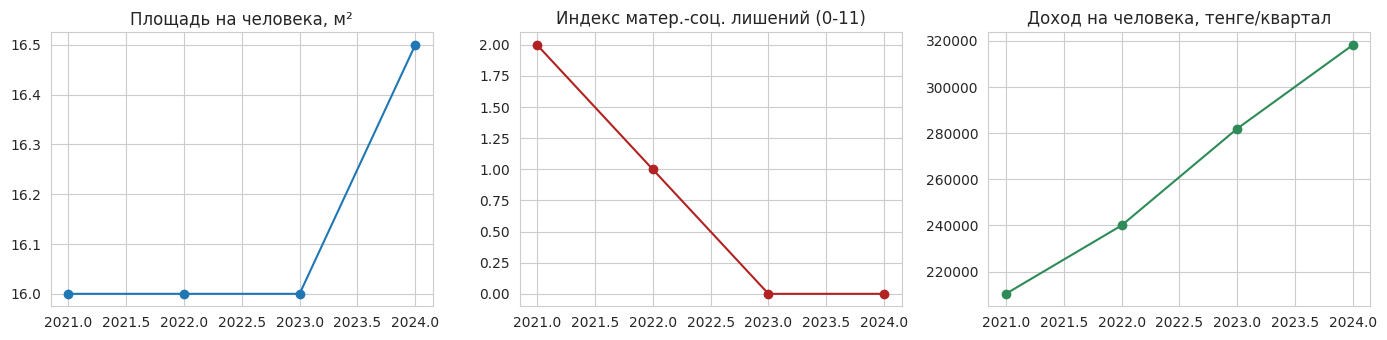

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(descriptive_dynamics["year"], descriptive_dynamics["median_area_per_person"], marker="o")
axes[0].set_title("Площадь на человека, м²")
axes[1].plot(descriptive_dynamics["year"], descriptive_dynamics["median_msd_count"], marker="o", color="firebrick")
axes[1].set_title("Индекс матер.-соц. лишений (0-11)")
axes[2].plot(descriptive_dynamics["year"], descriptive_dynamics["median_income_pc"], marker="o", color="seagreen")
axes[2].set_title("Доход на человека, тенге/квартал")
save(fig, "01_dynamics_2021_2024.png")


**2. Профиль депривации по 14 пунктам**

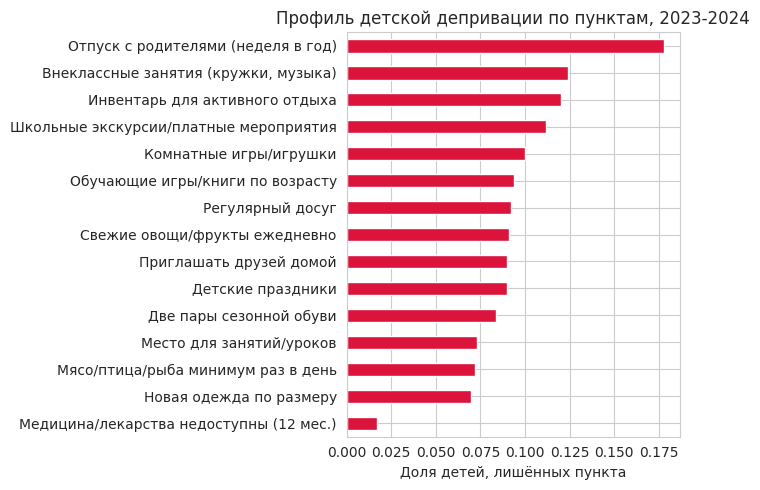

In [48]:
fig, ax = plt.subplots(figsize=(7, 5))
item_profile.sort_values().plot(kind="barh", ax=ax, color="crimson")
ax.set_xlabel("Доля детей, лишённых пункта")
ax.set_title("Профиль детской депривации по пунктам, 2023-2024")
save(fig, "02_item_level_deprivation_profile.png")


**3. Депривация по регионам**

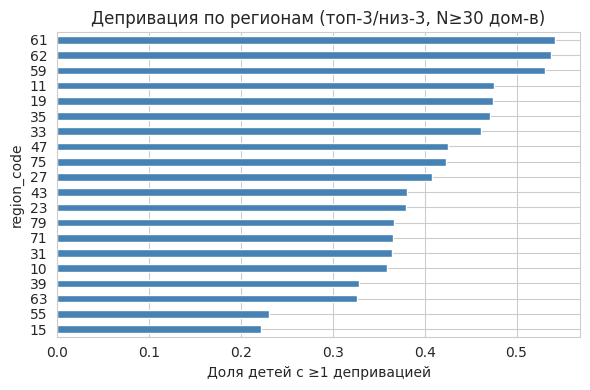

In [49]:
fig, ax = plt.subplots(figsize=(6, 4))
descriptive_by_region.sort_values("deprivation_rate")["deprivation_rate"].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Доля детей с ≥1 депривацией")
ax.set_title("Депривация по регионам (топ-3/низ-3, N≥30 дом-в)")
save(fig, "03_deprivation_by_region.png")


**4. Город/село и полнота семьи**

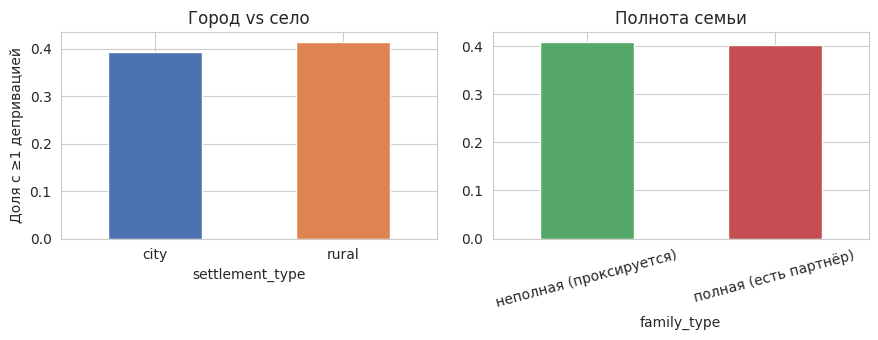

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
descriptive_by_settlement["deprivation_rate"].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Город vs село"); axes[0].set_ylabel("Доля с ≥1 депривацией"); axes[0].tick_params(axis='x', rotation=0)
descriptive_by_family["deprivation_rate"].plot(kind="bar", ax=axes[1], color=["#55A868", "#C44E52"])
axes[1].set_title("Полнота семьи"); axes[1].tick_params(axis='x', rotation=15)
save(fig, "04_settlement_and_family.png")


**5. Депривация по квартилям дохода на человека (D004)**

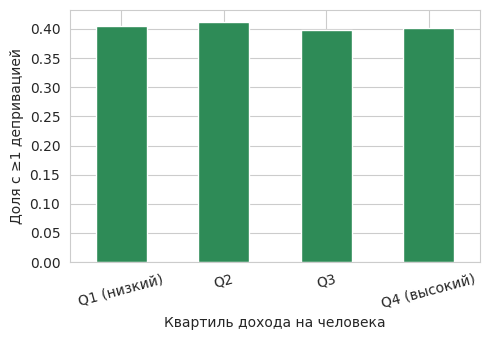

In [51]:
fig, ax = plt.subplots(figsize=(5, 3.5))
descriptive_by_income.groupby("income_quartile", observed=True)["deprivation_binary"].mean().plot(kind="bar", ax=ax, color="seagreen")
ax.set_ylabel("Доля с ≥1 депривацией"); ax.set_xlabel("Квартиль дохода на человека")
plt.xticks(rotation=15)
save(fig, "05_deprivation_by_income_quartile.png")


**6. Депривация и продовольственная безопасность**

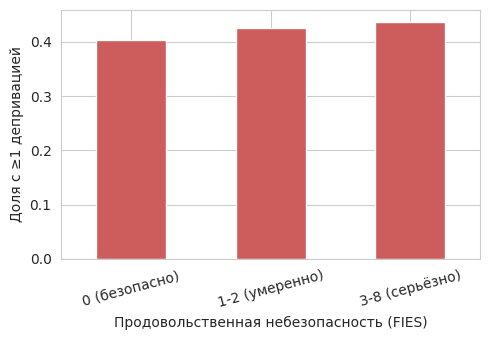

In [52]:
df_analysis["fies_group"] = pd.cut(df_analysis["food_insecurity_score"], [-0.1, 0, 2, 8],
                                    labels=["0 (безопасно)", "1-2 (умеренно)", "3-8 (серьёзно)"])
fies_rate = df_analysis.groupby("fies_group", observed=True)["deprivation_binary"].mean()
fig, ax = plt.subplots(figsize=(5, 3.5))
fies_rate.plot(kind="bar", ax=ax, color="indianred")
ax.set_ylabel("Доля с ≥1 депривацией"); ax.set_xlabel("Продовольственная небезопасность (FIES)")
plt.xticks(rotation=15)
save(fig, "06_deprivation_by_food_security.png")


**7. Депривация и число детей**

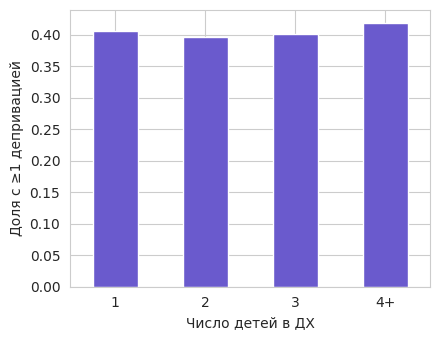

In [53]:
df_analysis["children_group"] = pd.cut(df_analysis["children_count"], [-0.1, 1, 2, 3, 20],
                                        labels=["1", "2", "3", "4+"])
children_rate = df_analysis.groupby("children_group", observed=True)["deprivation_binary"].mean()
fig, ax = plt.subplots(figsize=(4.5, 3.5))
children_rate.plot(kind="bar", ax=ax, color="slateblue")
ax.set_xlabel("Число детей в ДХ"); ax.set_ylabel("Доля с ≥1 депривацией")
plt.xticks(rotation=0)
save(fig, "07_deprivation_by_children_count.png")


**8. Депривация и занятость**

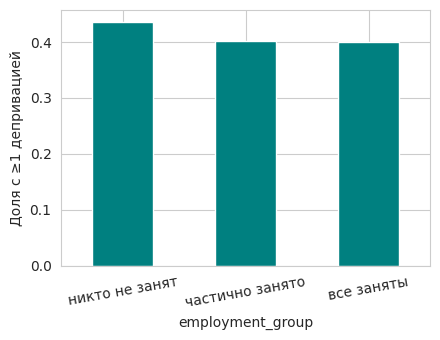

In [54]:
df_analysis["employment_group"] = pd.cut(df_analysis["employment_share"], [-0.1, 0, 0.5, 1.01],
                                          labels=["никто не занят", "частично занято", "все заняты"])
emp_rate = df_analysis.groupby("employment_group", observed=True)["deprivation_binary"].mean()
fig, ax = plt.subplots(figsize=(4.5, 3.5))
emp_rate.plot(kind="bar", ax=ax, color="teal")
ax.set_ylabel("Доля с ≥1 депривацией")
plt.xticks(rotation=10)
save(fig, "08_deprivation_by_employment.png")


**9. Алименты (выплата) и депривация**

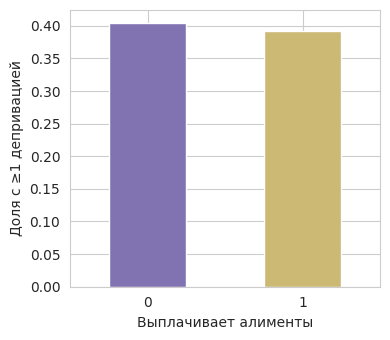

In [55]:
fig, ax = plt.subplots(figsize=(4, 3.5))
descriptive_by_alimony["deprivation_rate"].plot(kind="bar", ax=ax, color=["#8172B2", "#CCB974"])
ax.set_ylabel("Доля с ≥1 депривацией"); ax.set_xlabel("Выплачивает алименты")
plt.xticks(rotation=0)
save(fig, "09_deprivation_by_alimony.png")


## Milestone 15 — Двумерный анализ

### 15.1 Категориальные факторы (включая семью, алименты)

In [56]:
from scipy import stats

def chi2_cramers_v(df, factor, outcome="deprivation_binary"):
    tab = pd.crosstab(df[factor], df[outcome])
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    n = tab.sum().sum()
    k = min(tab.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan
    return pd.Series({"N": n, "chi2": round(chi2, 2), "dof": dof, "p_value": p, "cramers_v": round(v, 3)})

bivariate_categorical = pd.DataFrame({
    factor: chi2_cramers_v(df_analysis, factor)
    for factor in ["settlement_type", "region_code", "family_type", "alimony_paid", "children_group", "employment_group"]
}).T
bivariate_categorical


,N,chi2,dof,p_value,cramers_v
settlement_type,41252.0,18.62,1.0,1.597935e-05,0.021
region_code,41252.0,1281.64,19.0,3.028107e-260,0.176
family_type,41252.0,1.11,1.0,2.921719e-01,0.005
alimony_paid,41252.0,0.02,1.0,8.919637e-01,0.001
children_group,41252.0,7.49,3.0,5.774058e-02,0.013
employment_group,41240.0,15.20,2.0,5.008372e-04,0.019


### 15.2 Количественные факторы (включая доход D004)

In [57]:
continuous_factors = ["msd_count", "food_insecurity_score", "total_income_pc", "employment_income_pc",
                      "family_benefit_income_pc", "area_per_person", "rooms_per_person",
                      "household_size", "children_count", "employment_share"]
rows = []
for f in continuous_factors:
    sub = df_analysis[[f, "deprivation_binary", "deprivation_count"]].dropna()
    g0 = sub.loc[sub["deprivation_binary"] == 0, f]
    g1 = sub.loc[sub["deprivation_binary"] == 1, f]
    if len(g0) > 5 and len(g1) > 5:
        u_stat, p_mw = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    else:
        p_mw = np.nan
    rho, p_sp = stats.spearmanr(sub[f], sub["deprivation_count"])
    rows.append({"factor": f, "N": len(sub), "median_not_deprived": g0.median(), "median_deprived": g1.median(),
                 "mannwhitney_p": p_mw, "spearman_rho": round(rho, 3), "spearman_p": p_sp})
bivariate_continuous = pd.DataFrame(rows).set_index("factor")
bivariate_continuous


,N,median_not_deprived,median_deprived,mannwhitney_p,spearman_rho,spearman_p
factor,,,,,,
msd_count,40532,0.000000,0.000000,1.744196e-124,0.121,4.424292e-132
food_insecurity_score,39440,0.000000,0.000000,1.218456e-02,0.011,2.584468e-02
total_income_pc,40590,236250.000000,233416.696429,2.478620e-01,-0.012,1.956986e-02
employment_income_pc,40590,160000.000000,154954.500000,7.371292e-05,-0.029,3.970472e-09
family_benefit_income_pc,40590,0.000000,0.000000,1.726151e-01,0.012,1.574531e-02
area_per_person,40352,15.600000,15.750000,2.998016e-01,0.011,2.516803e-02
rooms_per_person,40352,0.666667,0.666667,9.184838e-02,-0.007,1.694484e-01
household_size,41252,4.000000,4.000000,6.704368e-03,0.026,9.504534e-08
children_count,41252,2.000000,2.000000,6.167176e-01,0.006,2.104058e-01


## Milestone 16 — Многомерная модель (логистическая регрессия)

**Единая основная спецификация** — все формы на равных правах с первого шага (не
поэтапное добавление):

```
deprivation_binary ~ material_ladder + log(income_per_capita) + food_insecurity_score +
                      area_per_person + household_size + children_count +
                      employment_share + incomplete_family + alimony_paid + family_benefit_flag +
                      settlement_rural + year_2024 + C(region_code)
```

In [58]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model_vars = ["deprivation_binary", "material_ladder", "total_income_pc", "food_insecurity_score",
              "area_per_person", "household_size", "children_count", "employment_share",
              "family_type", "alimony_paid", "family_benefit_flag", "settlement_type", "region_code", "year"]
model_df = df_analysis[model_vars].dropna().copy()
model_df["settlement_rural"] = (model_df["settlement_type"] == "rural").astype(int)
model_df["incomplete_family"] = (model_df["family_type"] == "неполная (проксируется)").astype(int)
model_df["region_code"] = model_df["region_code"].astype("category")
model_df["year_2024"] = (model_df["year"] == 2024).astype(int)
model_df["log_income_pc"] = np.log1p(model_df["total_income_pc"].clip(lower=0))

formula = ("deprivation_binary ~ material_ladder + log_income_pc + food_insecurity_score + "
           "area_per_person + household_size + children_count + employment_share + "
           "incomplete_family + alimony_paid + family_benefit_flag + settlement_rural + year_2024 + C(region_code)")
logit_model = smf.logit(formula, data=model_df).fit(disp=0)
print("N =", int(logit_model.nobs), "| Pseudo R2 =", round(logit_model.prsquared, 3))

model_terms = [c for c in logit_model.params.index if not c.startswith("C(region_code)") and c != "Intercept"]
pd.concat([
    np.exp(logit_model.params[model_terms]).rename("OR"),
    np.exp(logit_model.conf_int().loc[model_terms]).rename(columns={0: "CI_low", 1: "CI_high"}),
    logit_model.pvalues[model_terms].rename("p_value"),
], axis=1).round(3)


N = 37988 | Pseudo R2 = 0.026


,OR,CI_low,CI_high,p_value
material_ladder,0.939,0.907,0.971,0.000
log_income_pc,0.988,0.960,1.018,0.428
food_insecurity_score,1.002,0.972,1.033,0.895
area_per_person,0.998,0.996,1.000,0.056
household_size,1.046,1.019,1.074,0.001
children_count,0.927,0.898,0.957,0.000
employment_share,0.994,0.926,1.066,0.865
incomplete_family,1.023,0.974,1.074,0.369
alimony_paid,1.025,0.664,1.582,0.912
family_benefit_flag,0.998,0.935,1.065,0.953


In [59]:
region_terms = [c for c in logit_model.params.index if c.startswith("C(region_code)")]
lr_wald = logit_model.wald_test_terms()
print("Совместный Wald-тест по региону (H0: все региональные эффекты = 0):")
print(lr_wald.summary_frame().loc["C(region_code)"] if "C(region_code)" in lr_wald.summary_frame().index else lr_wald.summary_frame())


Совместный Wald-тест по региону (H0: все региональные эффекты = 0):
chi2              1.147338e+03
P>chi2           1.726749e-231
df constraint     1.900000e+01
Name: C(region_code), dtype: float64


**Интерпретация (описательная, без причинных выводов).** `log_income_pc` и
`material_ladder` включены **одновременно** — если оба значимы, они улавливают разные
аспекты материального положения (объективный доход vs субъективная самооценка); если
значим только один — второй, вероятно, избыточен относительно первого.
`incomplete_family`, `alimony_paid` и `family_benefit_flag` (получает ли ДХ гос. пособие
семье с детьми, D004/GR8) — протестированы на равных с остальными факторами внутри основной
модели, а не отдельно.

## Milestone 17 — Сложный дизайн выборки

Ни в `D00X_master_wide`, ни в `kv_vopr_detail` (D004) нет переменных весов, страт, PSU
— все оценки невзвешенные (см. Milestone 1.5).

## Milestone 18 — Мультиколлинеарность

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_vars = ["material_ladder", "log_income_pc", "food_insecurity_score", "area_per_person",
            "household_size", "children_count", "employment_share", "incomplete_family",
            "alimony_paid", "family_benefit_flag", "settlement_rural", "year_2024"]
X_vif = sm.add_constant(model_df[vif_vars])
vif_table = pd.DataFrame({
    "variable": vif_vars,
    "VIF": [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(vif_vars))]
}).round(2)
vif_table


,variable,VIF
0,material_ladder,1.03
1,log_income_pc,1.12
2,food_insecurity_score,1.02
3,area_per_person,1.32
4,household_size,3.88
5,children_count,3.32
6,employment_share,1.04
7,incomplete_family,1.11
8,alimony_paid,1.00
9,family_benefit_flag,1.16


## Milestone 19 — Взаимодействия

Материальное положение/доход/продбезопасность × город-село — сохраняется ли сила связи
одинаковой между городом и селом?

In [61]:
formula_int = (formula + " + material_ladder:settlement_rural + log_income_pc:settlement_rural + "
               "food_insecurity_score:settlement_rural + incomplete_family:settlement_rural")
logit_int = smf.logit(formula_int, data=model_df).fit(disp=0)
int_terms = ["material_ladder:settlement_rural", "log_income_pc:settlement_rural",
             "food_insecurity_score:settlement_rural", "incomplete_family:settlement_rural"]
pd.concat([
    logit_int.params[int_terms].rename("coef"), logit_int.pvalues[int_terms].rename("p_value"),
    np.exp(logit_int.params[int_terms]).rename("OR"),
], axis=1).round(3)


,coef,p_value,OR
material_ladder:settlement_rural,0.032,0.331,1.033
log_income_pc:settlement_rural,-0.033,0.248,0.967
food_insecurity_score:settlement_rural,-0.006,0.853,0.994
incomplete_family:settlement_rural,-0.196,0.000,0.822


Последняя строка — проверка **гетерогенности эффекта неполной семьи** между городом и селом: в раздельных моделях (Milestone 21) она даёт противоположные по знаку оценки, здесь это проверяется формальным тестом взаимодействия `incomplete_family × село`.

## Milestone 20 — Межгодовой анализ

Депривация — только 2023 vs 2024 (`year_2024` в модели выше). Для показателей,
сопоставимых все 4 года (жильё, материальная лестница, **доход D004**) — формальный тест
тренда.

In [62]:
_m = material.dropna(subset=["msd_count"])
print(f"msd_count vs год: rho={stats.spearmanr(_m['year'], _m['msd_count']).statistic:.3f}, "
      f"p={stats.spearmanr(_m['year'], _m['msd_count']).pvalue:.4f}")
_ml = material.dropna(subset=["material_ladder"])
print(f"material_ladder vs год: rho={stats.spearmanr(_ml['year'], _ml['material_ladder']).statistic:.3f}, "
      f"p={stats.spearmanr(_ml['year'], _ml['material_ladder']).pvalue:.4f}")
_inc = income_pc.dropna(subset=["total_income_pc"])
print(f"income_per_capita (D004) vs год: rho={stats.spearmanr(_inc['year'], _inc['total_income_pc']).statistic:.3f}, "
      f"p={stats.spearmanr(_inc['year'], _inc['total_income_pc']).pvalue:.4f}")


msd_count vs год: rho=-0.209, p=0.0000
material_ladder vs год: rho=0.101, p=0.0000
income_per_capita (D004) vs год: rho=0.259, p=0.0000


## Milestone 21 — Robustness checks

Ограниченный набор альтернативных спецификаций, включая **альтернативу доход vs
material_ladder** и раздельные проверки по подвыборкам.

In [63]:
def fit_logit(data, f):
    # убираем пустые категории региона в подвыборках (иначе сингулярная матрица)
    d = data.copy()
    if "region_code" in d and str(d["region_code"].dtype) == "category":
        d["region_code"] = d["region_code"].cat.remove_unused_categories()
    try:
        m = smf.logit(f, data=d).fit(disp=0, maxiter=300)
        if not m.mle_retvals.get("converged", True):
            m = smf.logit(f, data=d).fit(disp=0, method="bfgs", maxiter=3000)
        return m
    except Exception as e:
        print("fit failed:", type(e).__name__, str(e)[:100])
        return None

robustness_rows = [("Основная (>=1 депривация, income+ladder вместе)", logit_model)]

# (b) alt outcome >=2
model_df2 = df_analysis[["deprivation_count", "material_ladder", "total_income_pc", "food_insecurity_score",
                          "area_per_person", "household_size", "children_count", "employment_share",
                          "family_type", "alimony_paid", "family_benefit_flag", "settlement_type", "region_code", "year"]].dropna().copy()
model_df2["dep_ge2"] = (model_df2["deprivation_count"] >= 2).astype(int)
model_df2["settlement_rural"] = (model_df2["settlement_type"] == "rural").astype(int)
model_df2["incomplete_family"] = (model_df2["family_type"] == "неполная (проксируется)").astype(int)
model_df2["region_code"] = model_df2["region_code"].astype("category")
model_df2["year_2024"] = (model_df2["year"] == 2024).astype(int)
model_df2["log_income_pc"] = np.log1p(model_df2["total_income_pc"].clip(lower=0))
formula_ge2 = formula.replace("deprivation_binary", "dep_ge2")
robustness_rows.append(("Alt. outcome: >=2 депривации", fit_logit(model_df2, formula_ge2)))

# (c) только material_ladder (без дохода)
formula_no_income = formula.replace(" + log_income_pc", "")
robustness_rows.append(("Без дохода (только material_ladder)", fit_logit(model_df, formula_no_income)))

# (d) только доход (без лестницы)
formula_no_ladder = formula.replace("material_ladder + ", "")
robustness_rows.append(("Без лестницы (только доход)", fit_logit(model_df, formula_no_ladder)))

# (e) rooms_per_person вместо area_per_person
model_df3 = df_analysis[["deprivation_binary", "material_ladder", "total_income_pc", "food_insecurity_score",
                          "rooms_per_person", "household_size", "children_count", "employment_share",
                          "family_type", "alimony_paid", "family_benefit_flag", "settlement_type", "region_code", "year"]].dropna().copy()
model_df3["settlement_rural"] = (model_df3["settlement_type"] == "rural").astype(int)
model_df3["incomplete_family"] = (model_df3["family_type"] == "неполная (проксируется)").astype(int)
model_df3["region_code"] = model_df3["region_code"].astype("category")
model_df3["year_2024"] = (model_df3["year"] == 2024).astype(int)
model_df3["log_income_pc"] = np.log1p(model_df3["total_income_pc"].clip(lower=0))
formula_rooms = formula.replace("area_per_person", "rooms_per_person")
robustness_rows.append(("Alt. housing: rooms_per_person", fit_logit(model_df3, formula_rooms)))

# (f) 2023 / 2024 отдельно
formula_no_year = formula.replace(" + year_2024", "")
robustness_rows.append(("Только 2023", fit_logit(model_df[model_df["year"] == 2023], formula_no_year)))
robustness_rows.append(("Только 2024", fit_logit(model_df[model_df["year"] == 2024], formula_no_year)))

# (g) город / село
formula_no_settlement = formula.replace(" + settlement_rural", "")
robustness_rows.append(("Только город", fit_logit(model_df[model_df["settlement_rural"] == 0], formula_no_settlement)))
robustness_rows.append(("Только село", fit_logit(model_df[model_df["settlement_rural"] == 1], formula_no_settlement)))

def key_coef(m, name):
    if m is None or name not in m.params.index:
        return (np.nan, np.nan)
    return (round(np.exp(m.params[name]), 3), round(m.pvalues[name], 4))

robustness_summary = pd.DataFrame([
    {"specification": name, "N": int(m.nobs) if m is not None else np.nan,
     "converged": bool(m.mle_retvals.get("converged", True)) if m is not None else None,
     "OR_material_ladder": key_coef(m, "material_ladder")[0], "p_material_ladder": key_coef(m, "material_ladder")[1],
     "OR_income": key_coef(m, "log_income_pc")[0], "p_income": key_coef(m, "log_income_pc")[1],
     "OR_food_insecurity": key_coef(m, "food_insecurity_score")[0],
     "p_food_insecurity": key_coef(m, "food_insecurity_score")[1],
     "OR_incomplete_family": key_coef(m, "incomplete_family")[0],
     "p_incomplete_family": key_coef(m, "incomplete_family")[1]}
    for name, m in robustness_rows
])
robustness_summary


fit failed: LinAlgError Singular matrix


/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,specification,N,converged,OR_material_ladder,p_material_ladder,OR_income,p_income,OR_food_insecurity,p_food_insecurity,OR_incomplete_family,p_incomplete_family
0,"Основная (>=1 депривация, income+ladder вместе)",37988.0,True,0.939,0.0003,0.988,0.4279,1.002,0.8952,1.023,0.3688
1,Alt. outcome: >=2 депривации,37988.0,True,0.936,0.0009,0.985,0.3594,0.982,0.3019,0.987,0.6545
2,Без дохода (только material_ladder),37988.0,True,0.939,0.0003,NaN,NaN,1.002,0.8847,1.024,0.3433
3,Без лестницы (только доход),37988.0,True,NaN,NaN,0.988,0.4345,1.010,0.5140,1.022,0.3929
4,Alt. housing: rooms_per_person,37988.0,True,0.939,0.0003,0.988,0.4370,1.002,0.8980,1.026,0.3069
5,Только 2023,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Только 2024,19466.0,True,0.959,0.1042,0.992,0.7033,1.010,0.7035,1.044,0.2250
7,Только город,19280.0,True,0.914,0.0002,1.004,0.8248,1.002,0.9472,1.126,0.0007
8,Только село,18708.0,True,0.964,0.1427,0.971,0.1980,0.999,0.9656,0.923,0.0267


**Дополнительная проверка: индекс материально-социальных лишений взрослых (`msd_count`, D002).** Это самый сильный двумерный коррелят депривации детей (Milestone 15.2), но в основную модель он не включён (входит второй измеритель материального положения помимо самооценки и дохода). Проверяем, сохраняется ли его связь после контроля всех остальных факторов и меняет ли он выводы по самооценке/доходу.

In [64]:
_d = df_analysis[model_vars + ["msd_count"]].dropna().copy()
_d["settlement_rural"] = (_d["settlement_type"] == "rural").astype(int)
_d["incomplete_family"] = (_d["family_type"] == "неполная (проксируется)").astype(int)
_d["region_code"] = _d["region_code"].astype("category")
_d["year_2024"] = (_d["year"] == 2024).astype(int)
_d["log_income_pc"] = np.log1p(_d["total_income_pc"].clip(lower=0))
m_msd = fit_logit(_d, formula + " + msd_count")
_ci = np.exp(m_msd.conf_int())
msd_check = pd.DataFrame({
    "OR": np.exp(m_msd.params[["msd_count", "material_ladder", "log_income_pc"]]),
    "CI_low": _ci.loc[["msd_count", "material_ladder", "log_income_pc"], 0],
    "CI_high": _ci.loc[["msd_count", "material_ladder", "log_income_pc"], 1],
    "p_value": m_msd.pvalues[["msd_count", "material_ladder", "log_income_pc"]],
}).round(4)
print("N =", int(m_msd.nobs), "| Pseudo R2 =", round(m_msd.prsquared, 3))
msd_check


N = 37332 | Pseudo R2 = 0.041


,OR,CI_low,CI_high,p_value
msd_count,1.1402,1.1288,1.1516,0.0000
material_ladder,0.9376,0.9054,0.9709,0.0003
log_income_pc,0.9862,0.9572,1.0160,0.3610


## Milestone 22 — Пропуски и выбросы

In [65]:
outlier_check = df_analysis[["area_per_person", "rooms_per_person", "household_size", "children_count",
                             "msd_count", "food_insecurity_score", "total_income_pc"]].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T[["min", "1%", "5%", "50%", "95%", "99%", "max"]].round(0)
outlier_check


,min,1%,5%,50%,95%,99%,max
area_per_person,2.0,6.0,8.0,16.0,38.0,60.0,234.0
rooms_per_person,0.0,0.0,0.0,1.0,2.0,2.0,6.0
household_size,1.0,2.0,2.0,4.0,8.0,9.0,12.0
children_count,0.0,0.0,1.0,2.0,4.0,5.0,9.0
msd_count,0.0,0.0,0.0,0.0,6.0,10.0,11.0
food_insecurity_score,0.0,0.0,0.0,0.0,1.0,3.0,8.0
total_income_pc,0.0,38644.0,80000.0,235071.0,533122.0,751812.0,4907476.0


Выбросы не удаляются автоматически. `total_income_pc` на верхнем хвосте (99%)
может отражать как крупные легальные доходы (продажа имущества попадает в общий доход
за квартал), так и редкие ошибки ввода — без дополнительной валидации со стороны
поставщика различить это невозможно; для устойчивости результата доход используется в
логарифмированном виде (`log1p`), что снижает влияние отдельных экстремальных значений.

## Milestone 23 — Итоговая проверка гипотез

In [66]:
def sig_label(p, thresh=0.05):
    return "н/д" if p != p else ("значима" if p < thresh else "не значима")

ci_all = np.exp(logit_model.conf_int())
def logit_row(label, var, note=None):
    p = logit_model.pvalues.get(var, np.nan)
    ci = [round(ci_all.loc[var, 0], 3), round(ci_all.loc[var, 1], 3)] if var in ci_all.index else "—"
    interp = f"Ассоциация {sig_label(p)}" + (f"; {note}" if note else "")
    return [label, var, "Логит (полная модель), OR", round(np.exp(logit_model.params.get(var, np.nan)), 3), ci, p, interp]

hyp_rows = [
    ["Регион проживания", "region_code", "χ² (Cramér's V)", bivariate_categorical.loc["region_code", "cramers_v"], "—",
     bivariate_categorical.loc["region_code", "p_value"], f"Ассоциация {sig_label(bivariate_categorical.loc['region_code', 'p_value'])}"],
    ["Тип поселения (двумерно)", "settlement_type", "χ² (Cramér's V)", bivariate_categorical.loc["settlement_type", "cramers_v"], "—",
     bivariate_categorical.loc["settlement_type", "p_value"], f"Ассоциация {sig_label(bivariate_categorical.loc['settlement_type', 'p_value'])}"],
    logit_row("Тип поселения — село (с контролем)", "settlement_rural"),
    logit_row("Материальное положение (самооценка)", "material_ladder"),
    logit_row("Доход на человека, log (D004)", "log_income_pc"),
    logit_row("Продовольственная безопасность", "food_insecurity_score"),
    logit_row("Площадь жилья на человека", "area_per_person"),
    logit_row("Неполная семья (прокси)", "incomplete_family"),
    logit_row("Алименты выплачиваются (D004)", "alimony_paid", "фиксирует плательщиков, не получателей"),
    logit_row("Гос. пособие семье с детьми (D004/GR8)", "family_benefit_flag"),
    logit_row("Число детей в ДХ", "children_count"),
    logit_row("Размер ДХ", "household_size"),
    logit_row("Занятость взрослых", "employment_share"),
    logit_row("Год 2024 vs 2023", "year_2024"),
]
hypothesis_results = pd.DataFrame(hyp_rows, columns=["Hypothesis", "Variable", "Method", "Effect", "CI", "p_value", "Interpretation"])
hypothesis_results


,Hypothesis,Variable,Method,Effect,CI,p_value,Interpretation
0,Регион проживания,region_code,χ² (Cramér's V),0.176,—,3.028107e-260,Ассоциация значима
1,Тип поселения (двумерно),settlement_type,χ² (Cramér's V),0.021,—,1.597935e-05,Ассоциация значима
2,Тип поселения — село (с контролем),settlement_rural,"Логит (полная модель), OR",1.014,"[0.968, 1.063]",5.484106e-01,Ассоциация не значима
3,Материальное положение (самооценка),material_ladder,"Логит (полная модель), OR",0.939,"[0.907, 0.971]",2.801373e-04,Ассоциация значима
4,"Доход на человека, log (D004)",log_income_pc,"Логит (полная модель), OR",0.988,"[0.96, 1.018]",4.279096e-01,Ассоциация не значима
5,Продовольственная безопасность,food_insecurity_score,"Логит (полная модель), OR",1.002,"[0.972, 1.033]",8.951956e-01,Ассоциация не значима
6,Площадь жилья на человека,area_per_person,"Логит (полная модель), OR",0.998,"[0.996, 1.0]",5.640868e-02,Ассоциация не значима
7,Неполная семья (прокси),incomplete_family,"Логит (полная модель), OR",1.023,"[0.974, 1.074]",3.687547e-01,Ассоциация не значима
8,Алименты выплачиваются (D004),alimony_paid,"Логит (полная модель), OR",1.025,"[0.664, 1.582]",9.116571e-01,"Ассоциация не значима; фиксирует плательщиков,..."
9,Гос. пособие семье с детьми (D004/GR8),family_benefit_flag,"Логит (полная модель), OR",0.998,"[0.935, 1.065]",9.532272e-01,Ассоциация не значима


## Milestone 24 — Интерпретация

Разделяем (а) описательные факты, (б) статистические результаты, (в) интерпретацию.
Числа в блоке ниже **формируются кодом** из уже посчитанных таблиц (не вписаны вручную).

In [67]:
sig = lambda p: "значима" if p < 0.05 else "не значима"
dep_rate = df_analysis.groupby("year")["deprivation_binary"].mean()
top_items = item_profile.head(3)
def orci(var):
    return f"OR={np.exp(logit_model.params[var]):.3f} [{ci_all.loc[var,0]:.3f}; {ci_all.loc[var,1]:.3f}], p={logit_model.pvalues[var]:.3g} ({sig(logit_model.pvalues[var])})"

print("ОПИСАТЕЛЬНЫЕ ФАКТЫ")
print(f"- Доля детей с ≥1 депривацией: 2023 — {dep_rate.get(2023, float('nan')):.1%}, 2024 — {dep_rate.get(2024, float('nan')):.1%}.")
print("- Самые частые лишения: " + "; ".join(f"{k} ({v:.1%})" for k, v in top_items.items()) + ".")
print(f"- Село vs город: {descriptive_by_settlement.loc['rural','deprivation_rate']:.1%} vs {descriptive_by_settlement.loc['city','deprivation_rate']:.1%}.")
print()
print("СТАТИСТИЧЕСКИЕ РЕЗУЛЬТАТЫ (полная модель, N=%d)" % logit_model.nobs)
for lab, var in [("Материальная лестница", "material_ladder"), ("log дохода на человека (D004)", "log_income_pc"),
                 ("Продбезопасность (FIES)", "food_insecurity_score"), ("Площадь на человека", "area_per_person"),
                 ("Неполная семья", "incomplete_family"), ("Алименты выплачиваются", "alimony_paid"),
                 ("Гос. пособие семье с детьми", "family_benefit_flag"), ("Село", "settlement_rural"),
                 ("Число детей", "children_count"), ("Размер ДХ", "household_size")]:
    print(f"- {lab}: {orci(var)}")
print(f"- Регион: двумерно Cramér's V={bivariate_categorical.loc['region_code','cramers_v']}, p={bivariate_categorical.loc['region_code','p_value']:.2g}.")
n_lad = int((robustness_summary["p_material_ladder"] < 0.05).sum()); n_lad_tot = int(robustness_summary["p_material_ladder"].notna().sum())
n_inc = int((robustness_summary["p_income"] < 0.05).sum()); n_inc_tot = int(robustness_summary["p_income"].notna().sum())
print(f"- Устойчивость: material_ladder значима в {n_lad} из {n_lad_tot} спецификаций; доход — в {n_inc} из {n_inc_tot}.")
q_rates = df_analysis.groupby(pd.qcut(df_analysis["total_income_pc"], 4), observed=True)["deprivation_binary"].mean()
print(f"- Доля депривации по квартилям дохода на человека (D004): {q_rates.min():.1%}–{q_rates.max():.1%} (практически плоско); "
      f"по самооценке материального положения (1→6): {df_analysis.groupby('material_ladder')['deprivation_binary'].mean().round(3).tolist()}.")
_ip = logit_int.pvalues["incomplete_family:settlement_rural"]; _io = np.exp(logit_int.params["incomplete_family:settlement_rural"])
print(f"- Взаимодействие «неполная семья × село»: OR={_io:.3f}, p={_ip:.3g} ({'эффект различается между городом и селом' if _ip < 0.05 else 'различие не подтверждено'}).")
print(f"- Индекс материально-социальных лишений взрослых (D002) при добавлении в модель: OR={np.exp(m_msd.params['msd_count']):.3f} за пункт, "
      f"p={m_msd.pvalues['msd_count']:.3g} ({sig(m_msd.pvalues['msd_count'])}); при этом material_ladder: p={m_msd.pvalues['material_ladder']:.3g}, "
      f"log дохода: p={m_msd.pvalues['log_income_pc']:.3g}.")
print(f"- Pseudo R² модели: {logit_model.prsquared:.3f} (объяснительная сила невысока — депривация в основном не объясняется измеренными факторами).")


ОПИСАТЕЛЬНЫЕ ФАКТЫ
- Доля детей с ≥1 депривацией: 2023 — 42.1%, 2024 — 38.7%.
- Самые частые лишения: Отпуск с родителями (неделя в год) (17.8%); Внеклассные занятия (кружки, музыка) (12.4%); Инвентарь для активного отдыха (12.0%).
- Село vs город: 41.4% vs 39.4%.

СТАТИСТИЧЕСКИЕ РЕЗУЛЬТАТЫ (полная модель, N=37988)
- Материальная лестница: OR=0.939 [0.907; 0.971], p=0.00028 (значима)
- log дохода на человека (D004): OR=0.988 [0.960; 1.018], p=0.428 (не значима)
- Продбезопасность (FIES): OR=1.002 [0.972; 1.033], p=0.895 (не значима)
- Площадь на человека: OR=0.998 [0.996; 1.000], p=0.0564 (не значима)
- Неполная семья: OR=1.023 [0.974; 1.074], p=0.369 (не значима)
- Алименты выплачиваются: OR=1.025 [0.664; 1.582], p=0.912 (не значима)
- Гос. пособие семье с детьми: OR=0.998 [0.935; 1.065], p=0.953 (не значима)
- Село: OR=1.014 [0.968; 1.063], p=0.548 (не значима)
- Число детей: OR=0.927 [0.898; 0.957], p=3.53e-06 (значима)
- Размер ДХ: OR=1.046 [1.019; 1.074], p=0.000676 (значима)
- Ре

**Интерпретация (без причинных выводов).** Наблюдательный дизайн: обнаруженные ассоциации не
доказывают, что фактор *вызывает* депривацию. Низкий Pseudo R² означает, что измеренные
характеристики домохозяйства объясняют лишь малую часть различий — значимость при N≈38 тыс. не
равна большой практической значимости (см. величины OR и Cramér's V). Связь депривации с самооценкой немонотонна на краях шкалы (крайние категории малочисленны — см. `descriptive_by_ladder`), поэтому OR=0.94 на
одну ступень — это усреднённая оценка тренда, а не строгий градиент. Доход и самооценка
материального положения включены одновременно: значима самооценка, но не доход — субъективное
и «лишенческое» (msd_count) измерение благополучия несёт информацию о депривации детей сверх квартального дохода (доход измерен за один
квартал и может быть волатилен). Алименты (выплата) измеряют плательщика, а не получателя — прямого
вывода о депривации детей-получателей сделать нельзя.

## Milestone 25 — Итоговые выводы

### Основные результаты
Числовые результаты — в блоке выше (формируется кодом). Качественно:
1. Модуль депривации детей есть только в 2023–2024; данные за 2021–2022 не позволяют оценить
   депривацию (структурное ограничение анкеты).
2. Самые частые лишения — «развивающие/досуговые» (отпуск с родителями, внеклассные занятия,
   спортинвентарь), а не базовые нужды (одежда, еда).
3. Самые сильные предикторы среди измеренных — индекс материально-социальных лишений взрослых (D002) и самооценка
   материального положения; регион различает уровень депривации сильнее, чем тип поселения.
4. Реальный доход D004, продовольственная безопасность, площадь на человека, полнота семьи и
   выплата алиментов не дают устойчивой самостоятельной ассоциации после контроля остальных
   факторов (проверяйте знак/значимость в блоке выше и в `robustness_summary`).
5. Государственное пособие семье с детьми (D004/GR8, колонка подтверждена валидацией)
   включено в модель как бинарный признак наравне с остальными.
6. Колонка «алименты (получено)» (GR16) не прошла внешнюю валидацию и в выводах не используется.

### Проверка основной гипотезы
Гипотеза подтверждается **частично**. Значимые ассоциации после контроля остальных факторов:
регион (умеренный эффект), материальное положение — и самооценка (выше уровень → ниже шансы
депривации), и индекс материально-социальных лишений взрослых (`msd_count`, самый сильный предиктор: OR≈1.14 на
пункт; Milestone 21) — и структура домохозяйства (больше членов ДХ → выше шансы; больше детей при
контроле размера ДХ → ниже). Тип поселения значим только двумерно (эффект очень слабый) и не
значим в полной модели. Реальный доход (D004), продовольственная безопасность, площадь на
человека, занятость, полнота семьи в целом, алименты (выплата) и получение гос. пособия семье с
детьми самостоятельной значимой связи в полной модели не показали.

### Проверка производной гипотезы (Н1′)
Профиль по пунктам построен (Milestone 13.5, график 2). Полнота семьи в полной модели не
значима, но эффект **неоднородный**: в раздельных моделях по городу и селу оценки противоположны
по знаку (см. `robustness_summary` и тест взаимодействия в Milestone 19; вывод — по его p-value в
блоке выше). Это чувствительность к спецификации/подвыборке, а не устойчивый общий результат.

### Ограничения
- Депривация детей измерена только за 2023–2024; нет весов/страт/PSU (все оценки невзвешенные).
- D004: надёжно декодированы доход по найму, пенсии, пособия семьям, совокупный доход,
  алименты выплаченные; остальные категории дохода расшифрованы только по порядку бланка и
  входят лишь в сумму; GR16 (алименты получено) не подтверждена. Файл D004 — построчная выгрузка
  без словаря столбцов, поэтому расшифровка выполнена эмпирически.
- 2021: нет возраста членов ДХ (наличие детей определить нельзя); регион до/после 2022 сопоставим частично.
- Полнота семьи — прокси по отсутствию партнёра в составе ДХ.
- Доход — за один квартал (волатилен); сложные доходы (напр. разовая продажа имущества) входят в сумму.
- Наблюдательный дизайн — только ассоциации.

### Направления дальнейшего исследования
1. Получить от поставщика словарь столбцов `kv_vopr_11` и подтвердить/опровергнуть расшифровку GR9–GR23, включая алименты.
2. Использовать среднегодовой/квантильный доход по 4 кварталам вместо квартального (устойчивее).
3. Многоуровневая модель (домохозяйства внутри регионов) при наличии PSU/страт.
4. Панельные переходы (появление ребёнка → изменение дохода/жилья) для корректной проверки Н2.
5. Уточнить конструкцию «неполной семьи» (гражданский брак, расширенные семьи).


---
# ЧАСТЬ II. Milestone 26 — Что связано с наличием детей в домохозяйстве (гипотеза Н2)

**Гипотеза Н2:** шансы наличия детей в домохозяйстве выше при собственном благоустроенном
жилье и стабильно высоком доходе. Это **другая зависимая переменная** (`has_children`, а
не депривация детей) — самостоятельная модель, но построенная по тем же принципам и с
теми же источниками (D002/D004/D006/D008 на равных), доступна 2022–2024 (2021 исключён —
нет данных о возрасте членов ДХ).

Доход берётся **сразу из D004** (`total_income_pc`, без промежуточного использования
`TOTAL_EXPENDITURE` как временной прокси).

In [68]:
def build_children_presence(y):
    cols = ["HOUSEHOLD_ID", "d006__VLAD1", "d006__OB_PL", "d006__KOL_K", "d008__KOL_CHL",
            "TE", "K"] + list(AMENITY_COLS.values())
    if y in (2023, 2024):
        cols += ["d002_ocenka__GR40"]
    else:
        cols += ["d008__GOD_ROJD", "NOMP"]
    df = load_csv(y, usecols=cols)

    if y in (2023, 2024):
        has_child = df.groupby("HOUSEHOLD_ID")["d002_ocenka__GR40"].transform(lambda s: (s == 1).any())
    else:
        is_child = (y - df["d008__GOD_ROJD"]) < 18
        has_child = df.assign(is_child=is_child).groupby("HOUSEHOLD_ID")["is_child"].transform("any")

    hh_size = df["d008__KOL_CHL"].replace(0, np.nan)
    amenity_score = sum((df[c] == 1).astype(float) for c in AMENITY_COLS.values())

    out = pd.DataFrame({
        "year": y, "household_id": df["HOUSEHOLD_ID"], "has_children": has_child.astype(int),
        "owned_housing": df["d006__VLAD1"].isin([1, 2]).astype(int),
        "area_per_person": df["d006__OB_PL"] / hh_size, "amenity_score": amenity_score,
        "household_size": df["d008__KOL_CHL"], "region_code": df["TE"],
        "settlement_type": df["K"].map({1: "city", 2: "rural"}),
    })
    del df; gc.collect()
    return out.drop_duplicates(subset=["household_id"])

children_presence = pd.concat([build_children_presence(y) for y in (2022, 2023, 2024)], ignore_index=True)

income_for_presence = d004_income.groupby(["year", "household_id"])["total_income"].mean().reset_index()
children_presence = children_presence.merge(income_for_presence, on=["year", "household_id"], how="left")
children_presence["income_per_capita"] = children_presence["total_income"] / children_presence["household_size"].replace(0, np.nan)
children_presence["log_income_pc"] = np.log1p(children_presence["income_per_capita"].clip(lower=0))

children_presence["has_children"].value_counts(normalize=True).round(3)


,proportion
has_children,
1,0.529
0,0.471


### 26.1 Двумерные связи

In [69]:
cp_continuous = ["area_per_person", "amenity_score", "income_per_capita"]
rows = []
for f in cp_continuous:
    sub = children_presence[[f, "has_children"]].dropna()
    g0 = sub.loc[sub["has_children"] == 0, f]
    g1 = sub.loc[sub["has_children"] == 1, f]
    u_stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    rows.append({"factor": f, "median_no_children": g0.median(), "median_with_children": g1.median(), "p_value": p})
pd.DataFrame(rows).set_index("factor").round(3)


,median_no_children,median_with_children,p_value
factor,,,
area_per_person,30.500,15.600,0.0
amenity_score,4.000,3.000,0.0
income_per_capita,389940.312,229489.975,0.0


In [70]:
tab_owned = pd.crosstab(children_presence["owned_housing"], children_presence["has_children"])
chi2_owned, p_owned, _, _ = stats.chi2_contingency(tab_owned)
print(f"Собственное жильё x наличие детей: χ²={chi2_owned:.2f}, p={p_owned:.4g}")
children_presence.groupby("owned_housing")["has_children"].mean().round(3)


Собственное жильё x наличие детей: χ²=11.41, p=0.0007287


,has_children
owned_housing,
0,0.494
1,0.531


### 26.2 Логистическая регрессия

In [71]:
cp_model_df = children_presence[["has_children", "owned_housing", "area_per_person", "amenity_score",
                                  "log_income_pc", "settlement_type", "region_code", "year"]].dropna().copy()
cp_model_df["settlement_rural"] = (cp_model_df["settlement_type"] == "rural").astype(int)
cp_model_df["region_code"] = cp_model_df["region_code"].astype("category")
cp_model_df = pd.get_dummies(cp_model_df, columns=["year"], prefix="year", drop_first=True, dtype=int)
year_dummy_cols = [c for c in cp_model_df.columns if c.startswith("year_")]

formula_cp = ("has_children ~ owned_housing + area_per_person + amenity_score + log_income_pc + "
              "settlement_rural + " + " + ".join(year_dummy_cols) + " + C(region_code)")
logit_cp = smf.logit(formula_cp, data=cp_model_df).fit(disp=0)
cp_terms = [c for c in logit_cp.params.index if not c.startswith("C(region_code)") and c != "Intercept"]
pd.concat([
    np.exp(logit_cp.params[cp_terms]).rename("OR"),
    np.exp(logit_cp.conf_int().loc[cp_terms]).rename(columns={0: "CI_low", 1: "CI_high"}),
    logit_cp.pvalues[cp_terms].rename("p_value"),
], axis=1).round(3)


,OR,CI_low,CI_high,p_value
owned_housing,1.047,0.907,1.210,0.531
area_per_person,0.938,0.935,0.940,0.000
amenity_score,0.944,0.919,0.969,0.000
log_income_pc,0.083,0.077,0.090,0.000
settlement_rural,1.090,0.998,1.190,0.055
year_2023,1.091,1.018,1.169,0.014
year_2024,1.597,1.487,1.715,0.000


**Замечание по спецификации.** `household_size` намеренно не включён как
регрессор — наличие детей почти тавтологически увеличивает размер домохозяйства.

### 26.3 Мультиколлинеарность

In [72]:
vif_cp_vars = ["owned_housing", "area_per_person", "amenity_score", "log_income_pc", "settlement_rural"] + year_dummy_cols
X_vif_cp = sm.add_constant(cp_model_df[vif_cp_vars].astype(float))
pd.DataFrame({
    "variable": vif_cp_vars,
    "VIF": [variance_inflation_factor(X_vif_cp.values, i + 1) for i in range(len(vif_cp_vars))]
}).round(2)


,variable,VIF
0,owned_housing,1.00
1,area_per_person,1.20
2,amenity_score,2.16
3,log_income_pc,1.26
4,settlement_rural,2.11
5,year_2023,1.36
6,year_2024,1.42


### 26.4 Итог по Н2

**Интерпретация (описательная, без причинных выводов).** Смотрим знак и значимость в
таблице 26.2. Важные оговорки:
- Показатели «на человека» (доход, площадь) **математически снижаются** при рождении
  ребёнка в том же домохозяйстве (тот же ресурс делится на больше членов ДХ) —
  отрицательный коэффициент при `log_income_pc`/`area_per_person`, если он появится,
  вероятнее отражает этот композиционный артефакт, чем то, что гипотеза Н2 неверна по
  существу.
- Направление причинности неоднозначно и в другую сторону: жильё может
  благоустраиваться/приобретаться *после* рождения детей, а не *до* — обратная
  причинность минимум так же правдоподобна, как прямая, заявленная в гипотезе.
- Этап жизненного цикла домохозяйства (не измерен напрямую) — вероятный конфаундер:
  молодые семьи чаще имеют детей и чаще арендуют жильё.
- Корректная проверка Н2 потребовала бы дохода/жилья домохозяйства **до** рождения
  ребёнка (панельные переходы), что не реализуемо на текущих кросс-секционных разрезах.


In [73]:
cp_ci = np.exp(logit_cp.conf_int())
for var in ["owned_housing", "amenity_score", "area_per_person", "log_income_pc"]:
    p = logit_cp.pvalues[var]
    print(f"{var}: OR={np.exp(logit_cp.params[var]):.3f} [{cp_ci.loc[var,0]:.3f}; {cp_ci.loc[var,1]:.3f}], p={p:.3g} "
          f"({'значима' if p < 0.05 else 'не значима'})")


owned_housing: OR=1.047 [0.907; 1.210], p=0.531 (не значима)
amenity_score: OR=0.944 [0.919; 0.969], p=2.1e-05 (значима)
area_per_person: OR=0.938 [0.935; 0.940], p=0 (значима)
log_income_pc: OR=0.083 [0.077; 0.090], p=0 (значима)
